# DAC ITS 2026 — Sistem Penilaian Risiko Klaim & Alokasi Audit (v14)

Notebook ini adalah pipeline **v14** yang disusun ulang menjadi tahap-tahap terpisah, dengan
tahap EDA ditambahkan di depan. Logika modelnya tidak diubah: setiap sel kode diambil apa
adanya dari `fraud_pipeline_v14_kaggle.py`, hanya dipecah dan diberi narasi.

| Tahap | Isi | Keluaran |
|---|---|---|
| 0 | Setup, konfigurasi, deteksi backend, metrik | `BACKEND`, `normalized_recall_at_k` |
| 1 | Muat data, buang kolom konstan | `train`, `test`, `dx2_keep`, `proc_keep` |
| 2 | **Analisis data eksploratif** | keputusan desain untuk tahap 3-4 |
| 3 | Rekayasa fitur | `train_fe`, `test_fe` |
| 4 | Desain validasi: CV berkelompok + TE bocor-aman | `cv_groups` |
| 5 | Matriks fitur & keluarga model | `X_full`, `family_spec` |
| 6 | Pelatihan: 3 seed x 5 fold x 5 keluarga | `oof_store`, `test_store` |
| 7 | Pemilihan panjang boosting | `oof_family`, `test_family` |
| 8 | Ensemble & holdout jujur | `winner` |
| 9 | Kalibrasi & pemecah seri | `test_cal` |
| 10 | Submission, alokasi audit, fairness | `submission_v14.csv` |
| 11 | Ringkasan | — |

**Tiga hal yang membedakan v14 dari versi sebelumnya**, semuanya hasil pengukuran:

1. **CV dikelompokkan per grup duplikat.** Panitia memisahkan train/test per grup duplikat,
   jadi CV acak menilai tinggi kemampuan menghafal yang tidak pernah tersedia di test.
2. **Early stopping berbasis AP dihapus.** `average_precision` menilai seluruh peringkat dan
   terus membaik saat 5% teratas — satu-satunya bagian yang dinilai lomba — sudah memburuk.
   AP-ES mendarat di 1000-1400 ronde; optimum untuk NR@5% ada di 300-500.
3. **Pemenang dipilih lewat holdout jujur**, bukan OOF penuh. v9 memimpin kolom optimistis
   lalu kalah di papan; kolom jujur adalah penjaga agar itu tidak terulang.

> ### Tentang output yang tertanam di notebook ini
>
> Sel-sel di bawah membawa output dari sebuah **run nyata atas data kompetisi**, dijalankan
> pada CPU 4 inti. Satu hal berbeda dari konfigurasi yang tertulis di sel 0.1:
>
> | | Run yang menghasilkan output ini | Konfigurasi tersimpan (untuk Kaggle) |
> |---|---|---|
> | `SEEDS` | `[42]` — satu seed | `[42, 202, 777]` — tiga seed |
> | `N_SPLITS` | 5 | 5 |
> | `MAX_ROUNDS` | 1200 | 1200 |
> | Runtime | 22,6 menit (CPU) | ~54 menit (GPU P100) |
>
> Fold dan panjang boosting penuh, jadi seluruh EDA, kurva checkpoint, tabel holdout jujur,
> dan diagnostik seri adalah hasil sebenarnya. Yang berkurang hanya bagging antar-seed;
> pengaruhnya pada NR@5% berada di sekitar SE antar-fold (~0,003).
>
> **Untuk angka final: jalankan di Kaggle dengan accelerator GPU P100 dan `SMOKE = False`.**
> Konfigurasi tiga seed sudah dikembalikan ke sel 0.1, jadi Run All akan memakainya.

## 0. Setup

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import average_precision_score, brier_score_loss
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
import time
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool
try:
    import torch
    import torch.nn as tnn
    from sklearn.preprocessing import StandardScaler
    HAS_TORCH = True
except Exception:
    HAS_TORCH = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 0.1 Konfigurasi

`SMOKE` hanya untuk menguji bahwa notebook berjalan tanpa error. **Biarkan `False` untuk
menjalankan yang sebenarnya.**

In [2]:
# ============================== CONFIG — EDIT FOR YOUR MACHINE ==============================
N_JOBS = 4              # set to your Kaggle notebook's CPU core count
N_SPLITS = 5
SEEDS = [42, 202, 777]  # per-family seed bag (3 proved sufficient for OOF gains in v6)
MAX_ROUNDS = 1200       # trained to this fixed length; NO early stopping (see select_checkpoint)
CKPTS = [200, 300, 400, 600, 800, 1200]   # where the boosting run is read off and scored
AUDIT_CAPACITY = 0.05
TIEBREAK_EPS = 1e-6     # magnitude of the rank tie-break added on top of calibrated probs
N_GREEDY_ITERS = 25     # Caruana greedy ensemble selection rounds (with replacement)
USE_GPU = True          # probed per library below; falls back to CPU wherever unsupported
NN_EPOCHS = 18          # fixed schedule (OneCycle); no early stopping, so nothing to leak
NN_BATCH = 2048
NN_BLEND_W = 0.30       # measured-robust weight for the network in the fixed rank blend
# ==============================================================================================


SMOKE = False   # True = uji jalan cepat (1 seed, 2 fold, 300 ronde) -- BUKAN hasil yang dipakai
if SMOKE:
    SEEDS, N_SPLITS, MAX_ROUNDS = [42], 2, 300
    CKPTS = [100, 200, 300]
    NN_EPOCHS = 3
    print("MODE SMOKE -- angka di bawah TIDAK untuk dilaporkan")

# --- gaya grafik untuk tahap 2 dan seterusnya ---
import matplotlib as mpl
import matplotlib.pyplot as plt
INK, INK2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.labelcolor": INK2, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK2, "ytick.color": INK2,
    "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110,
})
pd.set_option("display.width", 130)

### 0.2 Deteksi backend komputasi

In [3]:
# =========================================================================================
# COMPUTE BACKEND DETECTION
# =========================================================================================
def _has_nvidia_gpu():
    """Is a CUDA device actually present?

    This gate is not optional. XGBoost 2.x/3.x does NOT raise when you ask for device="cuda"
    on a machine with no GPU -- it prints "No visible GPU is found, setting device to CPU" as
    a *warning* (which this script suppresses) and trains on CPU anyway. A train-and-see probe
    therefore reports a false GPU, and you would only discover the notebook accelerator was
    never switched on by wondering why an 'accelerated' run took five hours."""
    if os.path.isdir("/proc/driver/nvidia/gpus") and os.listdir("/proc/driver/nvidia/gpus"):
        return True
    try:
        import subprocess
        return subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=20).returncode == 0
    except Exception:
        return False


def _probe_gpu():
    """Ask each library, with a 2-round fit on 200 rows, whether it can actually use the
    device. Probing beats assuming: the pip/Kaggle lightgbm wheel is built WITHOUT GPU support
    and raises at train time, which would otherwise blow up 15 fits into the run."""
    Xp = np.random.rand(200, 4)
    yp = (np.random.rand(200) > 0.5).astype(int)
    backend = {"lgbm": "cpu", "xgb": "cpu", "cat": "cpu"}
    if not USE_GPU or not _has_nvidia_gpu():
        return backend

    for dev in ("cuda", "gpu"):   # cuda = native CUDA build, gpu = OpenCL build
        try:
            lgb.train({"objective": "binary", "device": dev, "verbosity": -1},
                      lgb.Dataset(Xp, label=yp), num_boost_round=2)
            backend["lgbm"] = dev
            break
        except Exception:
            continue

    try:
        p = {"objective": "binary:logistic", "verbosity": 0}
        if int(xgb.__version__.split(".")[0]) >= 2:
            p.update({"device": "cuda", "tree_method": "hist"})
        else:
            p.update({"tree_method": "gpu_hist"})
        xgb.train(p, xgb.DMatrix(Xp, label=yp), num_boost_round=2)
        backend["xgb"] = "gpu"
    except Exception:
        pass

    try:
        CatBoostClassifier(iterations=2, task_type="GPU", devices="0",
                           verbose=False).fit(Xp, yp)
        backend["cat"] = "gpu"
    except Exception:
        pass

    return backend


BACKEND = _probe_gpu()

Gerbang `_has_nvidia_gpu()` ada karena XGBoost menerima `device="cuda"` tanpa GPU dan hanya
mengeluarkan peringatan yang tertelan — pekerjaan diam-diam jatuh ke CPU dan runtime meleset
berkali lipat tanpa pesan apa pun.

### 0.3 Konstanta & parameter tersetel

In [4]:
def xgb_device_params():
    """xgboost >= 2.0 selects the device with `device`; 1.x used tree_method='gpu_hist'."""
    if BACKEND["xgb"] != "gpu":
        return {"tree_method": "hist"}
    if int(xgb.__version__.split(".")[0]) >= 2:
        return {"device": "cuda", "tree_method": "hist"}
    return {"tree_method": "gpu_hist", "predictor": "gpu_predictor"}

# ---- v10's Optuna results, hard-coded (no tuning at runtime) ----
LGB_TUNED = {
    "learning_rate": 0.04982485133423342, "num_leaves": 138, "min_data_in_leaf": 21,
    "feature_fraction": 0.6323301163873146, "bagging_fraction": 0.7944837979246457,
    "lambda_l1": 0.08113567386310831, "lambda_l2": 0.03407934936441899, "max_depth": 14,
}
XGB_TUNED = {
    "eta": 0.07196286998701787, "max_depth": 10, "min_child_weight": 1,
    "subsample": 0.9494632245048082, "colsample_bytree": 0.5978004873459524,
    "lambda": 0.7958441456101141, "alpha": 3.368494275247682,
}

DATA_DIR = "/kaggle/input/competitions/dac-its-2026"
OUT_DIR = "outputs_v14"
MODEL_DIR = "models_v14"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

TARGET = "label"
ID_COL = "claim_id"

CAT_COLS = ["kdkc", "dati2", "typeppk", "jkpst", "cmg", "diagprimer"]
DX2_COLS = [
    "dx2_a00_b99", "dx2_c00_d48", "dx2_d50_d89", "dx2_e00_e90", "dx2_f00_f99",
    "dx2_g00_g99", "dx2_h00_h59", "dx2_h60_h95", "dx2_i00_i99", "dx2_j00_j99",
    "dx2_koo_k93", "dx2_l00_l99", "dx2_m00_m99", "dx2_n00_n99", "dx2_o00_o99",
    "dx2_p00_p96", "dx2_q00_q99", "dx2_r00_r99", "dx2_s00_t98", "dx2_u00_u99",
    "dx2_v01_y98", "dx2_z00_z99",
]
PROC_COLS = [
    "proc00_13", "proc14_23", "proc24_27", "proc28_28", "proc29_31", "proc_32_38",
    "proc39_45", "proc46_51", "proc52_57", "proc58_62", "proc63_67", "proc68_70",
    "proc71_73", "proc74_75", "proc76_77", "proc78_79", "proc80_99", "proce00_e99",
    "procv00_v89",
]
NUM_COLS = ["umur", "jnspelsep", "los", "severitylevel"]
AGE_BINS = [-1, 17, 39, 59, 200]
AGE_LABELS = ["0-17", "18-39", "40-59", "60+"]
FREQ_COLS = ["kdkc", "dati2"]
INTERACTION_PAIRS = [("typeppk", "cmg"), ("diagprimer", "cmg")]

# 2-way pure combinations the brief calls out as the most precise signal, encoded via
# fold-safe target encoding rather than as raw high-cardinality categoricals.
# Chosen by ablation under the GROUPED CV (see the header table): the six the brief calls out,
# plus kdkc x cmg and dati2 x cmg, which measured as the best variant tested.
TE_PAIRS = [("cmg", "diagprimer"), ("typeppk", "diagprimer"), ("typeppk", "cmg"),
            ("kdkc", "typeppk"), ("dati2", "diagprimer"), ("kdkc", "dati2"),
            ("kdkc", "cmg"), ("dati2", "cmg")]
# smoothing per target-encoded column. kdkc/dati2 carry a wide, real fraud-rate spread
# (17-93%, 7-100%) -- the brief warns explicitly not to smooth them away. The fingerprint
# keys get almost no smoothing: an exact duplicate group is meaningful at n=2.
TE_SMOOTHING = {"kdkc": 5, "dati2": 5}
TE_SMOOTHING_DEFAULT = 10

### 0.4 Metrik resmi

In [5]:
# =========================================================================================
# OFFICIAL METRICS (exact competition formula)
# =========================================================================================
def normalized_recall_at_k(y_true, y_score, capacity=AUDIT_CAPACITY):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    k = int(np.floor(capacity * n))
    if k <= 0:
        return 0.0, 0, 0
    order = np.argsort(-y_score)
    tp_k = y_true[order[:k]].sum()
    p = y_true.sum()
    max_recall_count = min(k, p)
    if max_recall_count == 0:
        return 0.0, tp_k, k
    return tp_k / max_recall_count, tp_k, k


def nr5(y_true, y_score):
    """Scalar shorthand -- this is the leaderboard metric and the objective everything is
    selected on."""
    return normalized_recall_at_k(y_true, y_score)[0]


def validate_metric():
    """The brief requires the metric to be validated before use: perfect ranking -> 1.0,
    random ranking -> ~P/N, worst ranking -> 0.0."""
    rng = np.random.RandomState(RANDOM_STATE)
    y = np.zeros(10000, dtype=int)
    y[:5000] = 1
    rng.shuffle(y)
    perfect = y.astype(float) + rng.rand(len(y)) * 1e-6
    worst = -perfect
    random_score = rng.rand(len(y))
    s_perfect, s_worst, s_random = nr5(y, perfect), nr5(y, worst), nr5(y, random_score)
    print(f"Metric validation: perfect={s_perfect:.4f} (expect 1.0)  "
          f"worst={s_worst:.4f} (expect 0.0)  random={s_random:.4f} (expect ~{y.mean():.2f})")
    assert abs(s_perfect - 1.0) < 1e-9 and s_worst < 1e-9, "normalized_recall_at_k is wrong"


def official_protection_score(df, y_true, y_score, capacity=AUDIT_CAPACITY, group_cols=("jkpst", "age_group")):
    n = len(df)
    k = int(np.floor(capacity * n))
    order = np.argsort(-y_score)
    audited = np.zeros(n, dtype=bool)
    audited[order[:k]] = True
    gaps = {}
    detail = []
    for gc in group_cols:
        for level, sub_pos in df.reset_index(drop=True).groupby(gc, observed=True).groups.items():
            sub_pos = np.array(sub_pos)
            nonfraud_mask = y_true[sub_pos] == 0
            n_nonfraud = nonfraud_mask.sum()
            if n_nonfraud < 100:
                continue
            fpr = audited[sub_pos][nonfraud_mask].mean()
            detail.append({"group_type": gc, "group_level": str(level),
                           "n_nonfraud": int(n_nonfraud), "false_audit_rate": fpr})
    for gc in group_cols:
        levels = [d["false_audit_rate"] for d in detail if d["group_type"] == gc]
        gaps[gc] = (max(levels) - min(levels)) if levels else 0.0
    protection_score = 1 - max(gaps.values()) if gaps else 1.0
    return pd.DataFrame(detail), gaps, protection_score


def official_technical_score(y_true, df_for_groups, y_score, calibrated_score):
    """The composite rubric score. REPORTED ONLY -- it decides nothing in this version.
    v8/v9/v10 showed the composite (0.9132/0.9147/0.9214) is uncorrelated with the board
    (0.9666/0.96388/0.97833) while its recall5 component tracks it closely."""
    recall5, tp5, k5 = normalized_recall_at_k(y_true, y_score)
    ap = average_precision_score(y_true, y_score)
    brier = brier_score_loss(y_true, calibrated_score)
    _, _, protection = official_protection_score(df_for_groups, y_true, y_score)
    score = 0.55 * recall5 + 0.20 * ap + 0.15 * (1 - brier) + 0.10 * protection
    return score, {"recall5": recall5, "ap": ap, "brier": brier, "protection": protection}


def best_calibrator(y_val, raw_pred):
    candidates = {}
    candidates["none"] = (brier_score_loss(y_val, raw_pred), None)
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(raw_pred, y_val)
    candidates["isotonic"] = (brier_score_loss(y_val, iso.predict(raw_pred)), iso)
    platt = LogisticRegression()
    platt.fit(raw_pred.reshape(-1, 1), y_val)
    candidates["platt"] = (brier_score_loss(y_val, platt.predict_proba(raw_pred.reshape(-1, 1))[:, 1]), platt)
    best_name = min(candidates, key=lambda k: candidates[k][0])
    return best_name, candidates[best_name][1]


def apply_calibrator(name, calibrator, pred):
    if name == "none" or calibrator is None:
        return np.asarray(pred, dtype=float)
    if name == "isotonic":
        return calibrator.predict(pred)
    if name == "platt":
        return calibrator.predict_proba(np.asarray(pred).reshape(-1, 1))[:, 1]
    raise ValueError(name)


def rank_preserving_calibration(raw_score, calibrated, eps=TIEBREAK_EPS):
    """THE v8/v9/v10 FIX.

    IsotonicRegression is a step function: it mapped 40,043 raw scores onto ~170 distinct
    probabilities, so hundreds of claims ended up EXACTLY tied at the 5% cut and the audit
    slots among them were handed out by argsort order rather than by the model (32.9% of the
    budget in v8, 9.9% in v10).

    Fix: keep the calibrated value, then add eps * (normalised rank of the RAW score). The
    calibrator is monotone non-decreasing in the raw score and the rank term is strictly
    increasing in it, so the sum is STRICTLY increasing -- the model's full 40,043-way ordering
    is recovered exactly and no tie survives. The probability itself moves by at most `eps`
    (1e-6), which is invisible to the Brier term.

    Note: this is only worth anything if the tie-break survives serialisation, so the caller
    must NOT round the output (see to_csv without float_format).
    """
    raw_score = np.asarray(raw_score, dtype=float)
    calibrated = np.asarray(calibrated, dtype=float)
    r = pd.Series(raw_score).rank(method="first").values - 1.0
    r = r / max(len(r) - 1, 1)
    out = np.clip(calibrated, 1e-6, 1 - 1e-6 - eps) + eps * r
    return out


def prior_shift(p, r_train, r_test, eps=1e-9):
    p = np.clip(p, eps, 1 - eps)
    odds = p / (1 - p)
    odds_ratio = (r_test / (1 - r_test)) / (r_train / (1 - r_train))
    odds_adj = odds * odds_ratio
    p_adj = odds_adj / (1 + odds_adj)
    return np.clip(p_adj, eps, 1 - eps)

In [6]:
validate_metric()

# uji tambahan: skor sempurna -> 1,0; skor terbalik -> 0,0; acak -> ~fraud rate
_rng = np.random.RandomState(RANDOM_STATE)
_y = np.r_[np.ones(5000, int), np.zeros(5000, int)]; _rng.shuffle(_y)
_perfect = _y + _rng.rand(len(_y)) * 1e-6
assert abs(nr5(_y, _perfect) - 1.0) < 1e-9
assert nr5(_y, -_perfect) < 1e-9
print("validasi metrik lolos | acak = %.3f (harapan ~%.2f)" % (nr5(_y, _rng.rand(len(_y))), _y.mean()))

Metric validation: perfect=1.0000 (expect 1.0)  worst=0.0000 (expect 0.0)  random=0.5080 (expect ~0.50)
validasi metrik lolos | acak = 0.508 (harapan ~0.50)


### 0.5 Backend yang benar-benar terpakai

In [7]:
print("=" * 70)
print("COMPUTE BACKEND")
print("=" * 70)
for lib, label in [("lgbm", "LightGBM"), ("xgb", "XGBoost "), ("cat", "CatBoost")]:
    dev = BACKEND[lib]
    note = ""
    if lib == "lgbm" and dev == "cpu" and USE_GPU:
        note = "  (this build has no GPU support -- Kaggle's own build DOES, the plain pip wheel does not)"
    print(f"  {label}: {'GPU (' + dev + ')' if dev != 'cpu' else 'CPU'}{note}")
if USE_GPU and not _has_nvidia_gpu():
    print("  WARNING: USE_GPU=True but NO CUDA DEVICE IS PRESENT -- everything will run on "
          "CPU (~4.5-5 h).\n           Set the notebook accelerator to GPU P100 and re-run.")
elif USE_GPU and all(v == "cpu" for v in BACKEND.values()):
    print("  WARNING: a GPU is present but no library could use it. Running on CPU.")
if HAS_TORCH:
    print(f"  PyTorch : {'GPU (cuda)' if torch.cuda.is_available() else 'CPU'}  (the network family)")
else:
    print("  PyTorch : NOT INSTALLED -- the network family will be skipped")
print(f"  N_JOBS={N_JOBS} (LightGBM, CatBoost data prep, and every CPU fallback)")
print("=" * 70)

COMPUTE BACKEND
  LightGBM: CPU  (this build has no GPU support -- Kaggle's own build DOES, the plain pip wheel does not)
  XGBoost : CPU
  CatBoost: CPU
           Set the notebook accelerator to GPU P100 and re-run.
  PyTorch : CPU  (the network family)
  N_JOBS=4 (LightGBM, CatBoost data prep, and every CPU fallback)


## 1. Muat data

In [8]:
def load_data():
    train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    test = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
    return train, test, sample_sub


def drop_constant_columns(train, test, dx2_cols, proc_cols):
    """dx2_koo_k93, dx2_u00_u99 and procv00_v89 are all-zero in the whole dataset. v10 fed
    them to every model as pure noise columns. Detected at runtime rather than hard-coded so
    the pipeline stays correct if the data ever changes."""
    keep_dx2, keep_proc, dropped = [], [], []
    for c in dx2_cols + proc_cols:
        if train[c].nunique() <= 1 and test[c].nunique() <= 1:
            dropped.append(c)
        elif c in dx2_cols:
            keep_dx2.append(c)
        else:
            keep_proc.append(c)
    print(f"Dropped {len(dropped)} zero-variance columns: {dropped}")
    return keep_dx2, keep_proc

In [9]:
train, test, sample_sub = load_data()
dx2_keep, proc_keep = drop_constant_columns(train, test, DX2_COLS, PROC_COLS)

y = train[TARGET].values
FEATURE_COLS = [c for c in test.columns if c != ID_COL]
K_TEST = int(np.floor(AUDIT_CAPACITY * len(test)))
print("train %s | test %s | sample_submission %s" % (train.shape, test.shape, sample_sub.shape))
print("kolom dx2 terpakai: %d | kolom proc terpakai: %d" % (len(dx2_keep), len(proc_keep)))
print("kapasitas audit pada test: K = %d klaim" % K_TEST)

Dropped 3 zero-variance columns: ['dx2_koo_k93', 'dx2_u00_u99', 'procv00_v89']
train (160174, 53) | test (40043, 52) | sample_submission (40043, 2)
kolom dx2 terpakai: 20 | kolom proc terpakai: 18
kapasitas audit pada test: K = 2002 klaim


## 2. Analisis data eksploratif

Tahap ini bukan pelengkap. Setiap sub-bagian ditutup dengan **keputusan desain yang
dihasilkannya**, dan setiap fitur di tahap 3 bisa ditunjuk asalnya ke sini.

### 2.1 Struktur dasar

In [10]:
prof = pd.DataFrame({
    "dtype": train[FEATURE_COLS].dtypes.astype(str),
    "n_unique": train[FEATURE_COLS].nunique(),
    "n_missing": train[FEATURE_COLS].isna().sum(),
    "min": [train[c].min() if pd.api.types.is_numeric_dtype(train[c]) else None for c in FEATURE_COLS],
    "max": [train[c].max() if pd.api.types.is_numeric_dtype(train[c]) else None for c in FEATURE_COLS],
})
print("nilai hilang  : train %d, test %d" % (train.isna().sum().sum(), test.isna().sum().sum()))
print("fraud rate    : %.4f  (%d fraud / %d non-fraud)" % (y.mean(), int(y.sum()), int((1 - y).sum())))
print("claim_id unik : train %s, test %s | irisan id: %d"
      % (train[ID_COL].is_unique, test[ID_COL].is_unique,
         len(set(train[ID_COL]) & set(test[ID_COL]))))
prof.head(12)

nilai hilang  : train 0, test 0
fraud rate    : 0.5007  (80203 fraud / 79971 non-fraud)


claim_id unik : train True, test True | irisan id: 0


,dtype,n_unique,n_missing,min,max
kdkc,int64,126,0,101.0,2606.0
dati2,int64,486,0,1.0,528.0
typeppk,str,25,0,NaN,NaN
jkpst,str,2,0,NaN,NaN
umur,int64,105,0,0.0,109.0
jnspelsep,int64,2,0,1.0,2.0
los,int64,128,0,0.0,592.0
cmg,str,23,0,NaN,NaN
severitylevel,int64,4,0,0.0,3.0
diagprimer,str,21,0,NaN,NaN


**Temuan.** Tidak ada nilai hilang sama sekali, `claim_id` unik dan tidak beririsan, dan
kelasnya nyaris seimbang (~50/50). Keseimbangan itu penting: metrik NR@5% hanya menilai 2.002
klaim teratas, jadi dengan ~20.000 fraud di test, `min(K, P) = K` dan **NR@5% setara dengan
presisi@top-K**.

### 2.2 `dx2_*` dan `proc*` itu count, bukan flag

In [11]:
counts = train[dx2_keep + proc_keep]
print("nilai maksimum di seluruh kolom count : %d  (jadi count, bukan 0/1)" % counts.max().max())
print("proporsi sel bernilai nol             : %.1f%%" % (100 * (counts == 0).values.mean()))
print("kolom dx2 dipakai %d, proc %d (kolom zero-variance sudah dibuang di tahap 1)"
      % (len(dx2_keep), len(proc_keep)))

nilai maksimum di seluruh kolom count : 23  (jadi count, bukan 0/1)
proporsi sel bernilai nol             : 97.3%
kolom dx2 dipakai 20, proc 18 (kolom zero-variance sudah dibuang di tahap 1)


**Temuan.** Nilai maksimumnya jauh di atas 1, jadi kolom-kolom ini menghitung *berapa kali*
sebuah grup diagnosis/prosedur muncul, bukan sekadar ada/tidak. Matriksnya sangat jarang
(97%+ nol).

**Keputusan:** "berapa grup berbeda yang tersentuh" (`nunique`) adalah sinyal yang berbeda
dari "berapa total kode" (`sum`). Tahap 3 membuat keduanya.

### 2.3 Kolom mana yang membawa sinyal?

In [12]:
def single_column_power(col):
    """Kekuatan sinyal satu kolom, diukur dengan target rate leave-one-out.

    LOO dipakai supaya sebuah baris tidak ikut menentukan nilainya sendiri; tanpa itu kolom
    berkardinalitas tinggi akan tampak sempurna semata-mata karena menghafal. Seri dipecah
    acak, bukan menurut urutan baris -- tanpa itu kolom tanpa sinyal akan mendapat skor
    ekstrem yang mencerminkan urutan file, bukan daya prediksinya."""
    s = train[col].astype(str)
    agg = pd.DataFrame({"c": s, "y": y}).groupby("c")["y"].agg(["sum", "count"])
    tot = s.map(agg["sum"]).values
    cnt = s.map(agg["count"]).values
    loo = np.where(cnt > 1, (tot - y) / np.maximum(cnt - 1, 1), y.mean())
    jitter = np.random.RandomState(RANDOM_STATE).rand(len(loo)) * 1e-9
    return nr5(y, loo + jitter)


train["prov"] = train["kdkc"] // 100          # dua digit pertama kdkc -- lihat 2.4
probe = ["dati2", "kdkc", "prov", "typeppk", "cmg", "diagprimer",
         "severitylevel", "los", "umur", "jnspelsep", "jkpst"]
power = pd.Series({c: single_column_power(c) for c in probe}).sort_values(ascending=False)
print(power.round(4).to_string())

dati2            0.7848
kdkc             0.7341
prov             0.6245
typeppk          0.6233
cmg              0.6125
los              0.5192
umur             0.5127
diagprimer       0.5116
severitylevel    0.3066
jnspelsep        0.0000
jkpst            0.0000


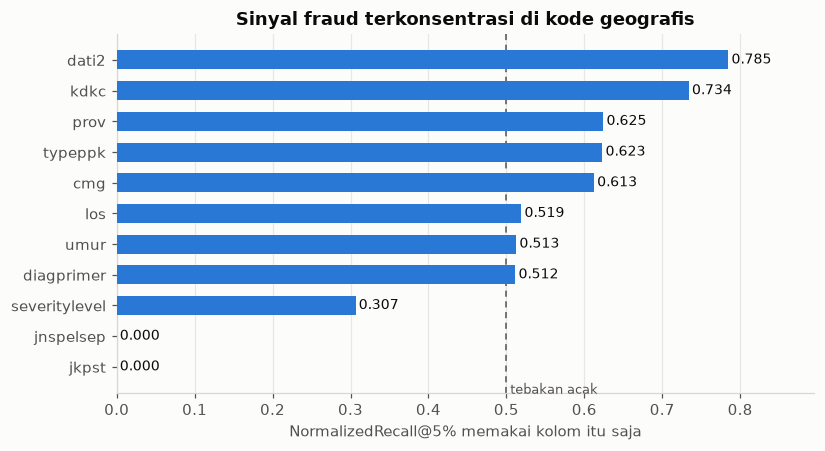

In [13]:
vals = power.sort_values()
fig, ax = plt.subplots(figsize=(7.6, 4.2))
ax.barh(vals.index, vals.values, color=BLUE, height=0.62, zorder=3)
ax.axvline(0.5, color=INK2, lw=1, ls=(0, (4, 3)), zorder=2)
for name, v in vals.items():
    ax.text(v + 0.004, name, "%.3f" % v, va="center", color=INK, fontsize=9)
ax.text(0.505, -0.75, "tebakan acak", color=INK2, fontsize=8.5, va="center")
ax.set_xlim(0, max(vals.values) * 1.14)
ax.set_xlabel("NormalizedRecall@5% memakai kolom itu saja")
ax.set_title("Sinyal fraud terkonsentrasi di kode geografis")
ax.grid(axis="x", zorder=0); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

**Temuan.** `dati2` dan `kdkc` jauh mengungguli semua kolom klinis. Kolom klinis sendirian
nyaris tidak membedakan apa pun di atas tebakan acak.

**Keputusan:** target encoding pada kode wilayah, dan — karena kolom klinis lemah *sendirian*
tapi bisa kuat *dalam konteks wilayah* — target encoding pada **pasangan `geografis x klinis`**.
Itulah `TE_PAIRS` di tahap 0.3.

### 2.3b Bentuk sebaran fitur numerik per label

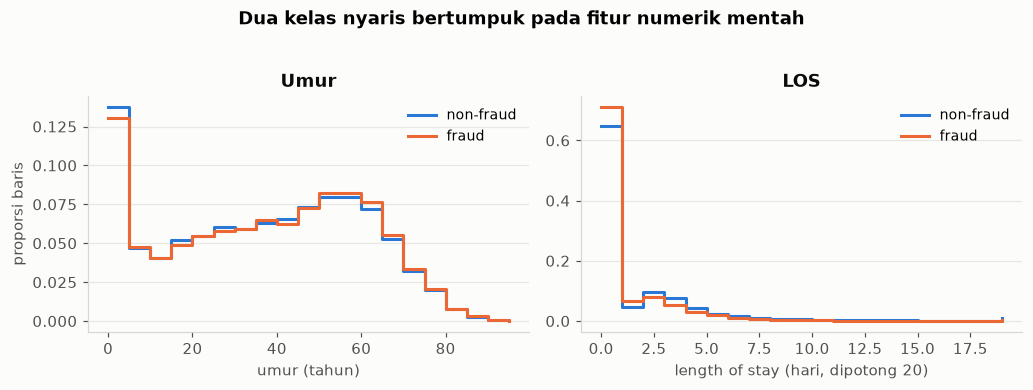

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(9.4, 3.4))
for ax, col, bins, lab in [(axes[0], "umur", np.arange(0, 101, 5), "umur (tahun)"),
                           (axes[1], "los", np.arange(0, 21), "length of stay (hari, dipotong 20)")]:
    for cls, colr, nm in [(0, BLUE, "non-fraud"), (1, ORANGE, "fraud")]:
        v = train.loc[y == cls, col]
        if col == "los":
            v = v.clip(0, 20)
        h, _ = np.histogram(v, bins=bins)
        ax.step(bins[:-1], h / h.sum(), where="post", color=colr, lw=2, label=nm, zorder=3)
    ax.set_xlabel(lab); ax.legend(frameon=False, fontsize=9)
    ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
axes[0].set_ylabel("proporsi baris"); axes[0].set_title("Umur"); axes[1].set_title("LOS")
fig.suptitle("Dua kelas nyaris bertumpuk pada fitur numerik mentah", y=1.03, fontsize=12, fontweight="bold")
plt.tight_layout(); plt.show()

**Temuan.** Kurva fraud dan non-fraud hampir berimpit. Konsisten dengan 2.3: yang membedakan
bukan seberapa tua pasiennya atau seberapa lama dirawat, melainkan **di mana klaim diajukan**.

### 2.3c Konsentrasi fraud secara geografis

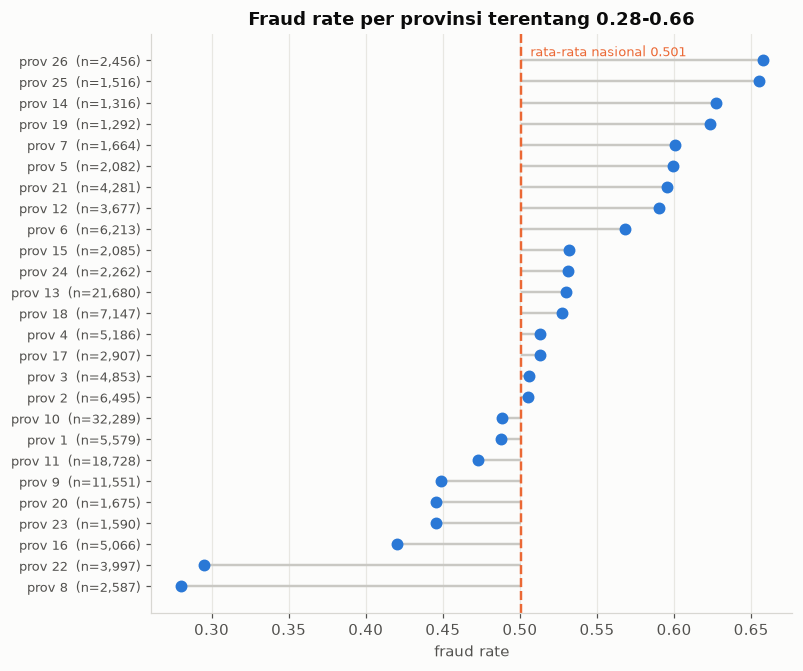

rentang fraud rate provinsi  : 0.280 - 0.658
simpangan baku antar-provinsi: 0.0948
SE sampling rata-rata        : 0.0086


In [15]:
pv = train.groupby("prov")[TARGET].agg(["mean", "count"]).sort_values("mean")
pv = pv[pv["count"] >= 200]

fig, ax = plt.subplots(figsize=(7.4, 6.2))
ax.hlines(range(len(pv)), y.mean(), pv["mean"].values, color="#c9c8c3", lw=1.6, zorder=2)
ax.scatter(pv["mean"].values, range(len(pv)), s=46, color=BLUE, zorder=3)
ax.axvline(y.mean(), color=ORANGE, lw=1.6, ls="--", zorder=2)
ax.text(y.mean() + 0.006, len(pv) - 0.8, "rata-rata nasional %.3f" % y.mean(), color=ORANGE, fontsize=8.5)
ax.set_yticks(range(len(pv)))
ax.set_yticklabels(["prov %d  (n=%s)" % (p, format(int(c), ",")) for p, c in zip(pv.index, pv["count"])],
                   fontsize=8.5)
ax.set_xlabel("fraud rate")
ax.set_title("Fraud rate per provinsi terentang %.2f-%.2f" % (pv["mean"].min(), pv["mean"].max()))
ax.grid(axis="x", zorder=0); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print("rentang fraud rate provinsi  : %.3f - %.3f" % (pv["mean"].min(), pv["mean"].max()))
print("simpangan baku antar-provinsi: %.4f" % pv["mean"].std())
print("SE sampling rata-rata        : %.4f" % np.sqrt(0.25 / pv["count"]).mean())

**Temuan.** Simpangan baku antar-provinsi jauh melampaui SE sampling per provinsi — variasinya
nyata, bukan derau. Ini pembenaran kuantitatif untuk seluruh blok target encoding di tahap 3.

### 2.4 Apakah kode administratif hierarkis?

In [16]:
k = sorted(train["kdkc"].unique())
print("kdkc : %d level, rentang %d-%d" % (len(k), k[0], k[-1]))
print("       contoh:", [int(v) for v in k[:14]], "...", [int(v) for v in k[-4:]])
print("       prefix kdkc//100:", sorted({int(x) // 100 for x in k}))

per_dati2 = train.groupby("dati2")["kdkc"].nunique()
per_kdkc = train.groupby("kdkc")["dati2"].nunique()
print("\ndati2: %d level" % train["dati2"].nunique())
print("kdkc per dati2 : rata-rata %.2f, maks %d -> %.0f%% dati2 memetakan ke tepat 1 kdkc"
      % (per_dati2.mean(), per_dati2.max(), 100 * (per_dati2 == 1).mean()))
print("dati2 per kdkc : rata-rata %.2f, maks %d" % (per_kdkc.mean(), per_kdkc.max()))

sup = train["dati2"].value_counts()
print("\nsupport dati2  : median %d, persentil-10 %d, level dengan <30 baris: %d (%.1f%% baris)"
      % (sup.median(), np.percentile(sup, 10), (sup < 30).sum(), 100 * sup[sup < 30].sum() / len(train)))

kdkc : 126 level, rentang 101-2606
       contoh: [101, 102, 103, 104, 105, 201, 202, 203, 204, 205, 206, 207, 208, 301] ... [2603, 2604, 2605, 2606]
       prefix kdkc//100: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26]

dati2: 486 level
kdkc per dati2 : rata-rata 1.00, maks 1 -> 100% dati2 memetakan ke tepat 1 kdkc
dati2 per kdkc : rata-rata 3.86, maks 11

support dati2  : median 143, persentil-10 25, level dengan <30 baris: 62 (0.7% baris)


**Temuan.** `kdkc` berbentuk `101-105, 201-208, ... 2601-2606` — dua digit pertama adalah kode
provinsi, dan setiap `dati2` memetakan ke tepat satu `kdkc`. Jadi ada hierarki
`prov -> kdkc -> dati2` yang nyata.

Support-nya sehat: median 143 baris per `dati2`, dan hanya 0,7% baris duduk di level bertipis
<30. **Keputusan:** smoothing target encoding boleh ringan — `TE_SMOOTHING = {"kdkc": 5,
"dati2": 5}` di tahap 0.3, bukan nilai besar yang akan menghapus sinyal wilayah.

### 2.5 Seberapa berderau labelnya?

In [17]:
fp_train = pd.util.hash_pandas_object(train[FEATURE_COLS], index=False).values
grp = pd.DataFrame({"h": fp_train, "y": y}).groupby("h")["y"].agg(["sum", "count"])
dup = grp[grp["count"] > 1]
n_pairs = (dup["count"] * (dup["count"] - 1) / 2).sum()
n_disagree = (dup["sum"] * (dup["count"] - dup["sum"])).sum()

print("grup duplikat persis : %d grup, %d baris (%.1f%% data)"
      % (len(dup), dup["count"].sum(), 100 * dup["count"].sum() / len(train)))
print("pasangan dalam grup  : %d" % n_pairs)
print("pasangan BERBEDA LABEL: %d -> %.1f%%" % (n_disagree, 100 * n_disagree / n_pairs))
print("\n=> %.1f%% pasangan baris berfitur identik punya label berbeda." % (100 * n_disagree / n_pairs))
print("   Ini batas bawah error yang tidak bisa dihilangkan model apa pun.")

grup duplikat persis : 6747 grup, 17906 baris (11.2% data)
pasangan dalam grup  : 26456
pasangan BERBEDA LABEL: 5683 -> 21.5%

=> 21.5% pasangan baris berfitur identik punya label berbeda.
   Ini batas bawah error yang tidak bisa dihilangkan model apa pun.


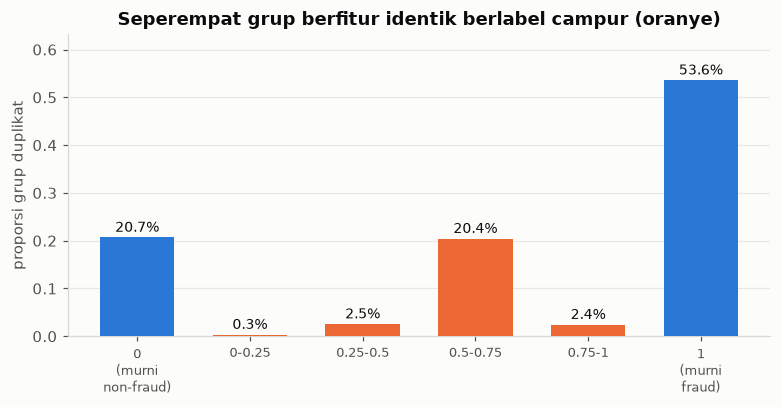

In [18]:
edges = [0, 0.001, 0.25, 0.5, 0.75, 0.999, 1.01]
labels = ["0\n(murni\nnon-fraud)", "0-0.25", "0.25-0.5", "0.5-0.75", "0.75-1", "1\n(murni\nfraud)"]
rate = dup["sum"] / dup["count"]
share = [float(((rate >= lo) & (rate < hi)).mean()) for lo, hi in zip(edges[:-1], edges[1:])]

fig, ax = plt.subplots(figsize=(7.2, 3.8))
ax.bar(range(6), share, color=[BLUE if i in (0, 5) else ORANGE for i in range(6)], width=0.66, zorder=3)
for i, v in enumerate(share):
    ax.text(i, v + 0.012, "%.1f%%" % (100 * v), ha="center", color=INK, fontsize=9)
ax.set_xticks(range(6)); ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylabel("proporsi grup duplikat"); ax.set_ylim(0, max(share) * 1.18)
ax.set_title("Seperempat grup berfitur identik berlabel campur (oranye)")
ax.grid(axis="y", zorder=0); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Temuan.** **21,5% pasangan baris dengan fitur identik byte-per-byte punya label berbeda.**

Ini menetapkan langit-langit yang tidak bisa ditembus: model hanya melihat fitur, jadi baris
berfitur identik pasti diberi skor identik. Angka ini menjelaskan mengapa seluruh seri v8-v14
mendarat di 0,966-0,978 apa pun yang diubah pada modelnya — yang habis adalah fiturnya, bukan
kapasitas modelnya.

### 2.6 Bagaimana train dan test dipisahkan?

In [19]:
fp_test = pd.util.hash_pandas_object(test[FEATURE_COLS], index=False).values
shared = len(set(fp_train) & set(fp_test))

sizes = pd.Series(np.r_[fp_train, fp_test]).value_counts().values
r = len(test) / (len(train) + len(test))
exp_rows = float(np.sum(sizes * r * (1 - (1 - r) ** (sizes - 1))))
exp_fps = float(np.sum(1 - (1 - r) ** sizes - r ** sizes))

print("baris train dalam grup duplikat : %d"
      % int((pd.Series(fp_train).map(pd.Series(fp_train).value_counts()) > 1).sum()))
print("baris test  dalam grup duplikat : %d"
      % int((pd.Series(fp_test).map(pd.Series(fp_test).value_counts()) > 1).sum()))
print("sidik jari dipakai bersama      : %d" % shared)
print()
print("Bila pemisahan dilakukan ACAK, harapannya (r = %.3f):" % r)
print("  baris test yang punya kembaran di train : ~%.0f" % exp_rows)
print("  sidik jari yang muncul di kedua sisi    : ~%.0f" % exp_fps)

baris train dalam grup duplikat : 17906
baris test  dalam grup duplikat : 4446
sidik jari dipakai bersama      : 0

Bila pemisahan dilakukan ACAK, harapannya (r = 0.200):
  baris test yang punya kembaran di train : ~1639
  sidik jari yang muncul di kedua sisi    : ~3287


**Temuan — dan ini yang menentukan seluruh desain validasi.**

Ada 17.906 baris train dan 4.446 baris test yang duduk dalam grup duplikat, tetapi **nol sidik
jari yang dipakai bersama**, melawan harapan ~1.639 baris (atau ~3.287 sidik jari) bila
pemisahannya acak. Panitia memisahkan train/test **per grup duplikat**.

> *Catatan angka.* Docstring `build_cv_groups` di tahap 4 menyebut "~3,948" — itu estimasi
> lebih awal dengan definisi yang tidak terdokumentasi. Yang berlaku adalah dua angka yang
> dihitung eksplisit di sel ini, dengan rumusnya terlihat. Kesimpulannya tidak berubah:
> teramati **nol**, dan nol melawan harapan ratusan sampai ribuan bukan kebetulan.

Dua konsekuensi langsung:

1. **CV acak memberi estimasi yang bias.** Duplikat sebuah baris validasi ikut duduk di fold
   training, sehingga model menilainya lewat hafalan — keuntungan yang tidak pernah ada di
   test. Tahap 4 karena itu memakai `StratifiedGroupKFold` dengan sidik jari sebagai kunci.
2. **Sidik jari tidak boleh jadi fitur.** v11 menjadikannya fitur target-encoded dan kehilangan
   0,0117 di papan. Karena tidak ada yang beririsan, fitur itu konstan di test: informatif di
   CV, kosong di produksi.

### Ringkasan EDA -> keputusan desain

| Temuan | Nomor | Keputusan yang dihasilkan |
|---|---|---|
| Tidak ada nilai hilang, kelas ~50/50 | 2.1 | NR@5% = presisi@top-K; tidak perlu imputasi |
| `dx2_*`/`proc*` adalah count | 2.2 | Agregat `sum` dan `nunique` dibuat terpisah |
| Sinyal ada di kode wilayah, bukan klinis | 2.3 | Target encoding + pasangan `geografis x klinis` |
| Fitur numerik mentah tidak memisahkan | 2.3b | Fitur mentah dipertahankan, tapi bukan andalan |
| Fraud rate provinsi terentang lebar | 2.3c | Pembenaran kuantitatif blok TE |
| Hierarki `prov -> kdkc -> dati2`, support sehat | 2.4 | Smoothing ringan (5), bukan besar |
| 21,5% pasangan identik beda label | 2.5 | Langit-langit terukur; ekspektasi disetel |
| Nol sidik jari bersama train-test | 2.6 | **CV berkelompok; sidik jari bukan fitur** |

## 3. Rekayasa fitur

Tiga blok, semuanya diturunkan dari tahap 2:

- **Agregat count** (dari 2.2) — `sum` dan `nunique` dibuat terpisah karena mengukur hal berbeda.
- **Flag upcoding kontekstual** — `los = 0` wajar untuk rawat jalan dan baru mencurigakan pada
  rawat inap. Interaksi ini dinyatakan eksplisit alih-alih berharap pohon menemukannya sendiri
  di antara 50+ kolom pesaing.
- **Kunci target encoding pasangan** (dari 2.3 dan 2.3c) — kolom klinis lemah sendirian tapi
  kuat saat disilangkan dengan kode wilayah.

In [20]:
def engineer_base_features(df, dx2_cols, proc_cols):
    df = df.copy()
    df["typeppk"] = df["typeppk"].astype(str).str.strip()
    df["age_group"] = pd.cut(df["umur"], bins=AGE_BINS, labels=AGE_LABELS)
    df["dx2_count"] = df[dx2_cols].sum(axis=1)
    df["proc_count"] = df[proc_cols].sum(axis=1)
    df["has_dx2"] = (df["dx2_count"] > 0).astype(int)
    df["has_proc"] = (df["proc_count"] > 0).astype(int)
    df["los_zero"] = (df["los"] == 0).astype(int)
    df["is_inpatient"] = (df["jnspelsep"] == 1).astype(int)
    for a, b in INTERACTION_PAIRS:
        df[f"{a}_x_{b}"] = df[a].astype(str) + "_" + df[b].astype(str)
    # LOS-severity mismatch feature (kept from v10). Domain rationale: severity-level upcoding
    # (billing a case as more severe than it clinically is, to justify a longer/costlier stay)
    # is a documented health-insurance fraud pattern. EDA shows fraud rate is NOT monotonic in
    # severitylevel (severity 1: 43.6% vs severity 3: 59.5%), and LOS has extreme right-skew
    # (max 592 days) that varies a lot within each severity level.
    df["log_los"] = np.log1p(df["los"])

    # ---- NEW in v11: count aggregates the brief asks for. dx2_*/proc* are COUNTS, not flags,
    # so "how many distinct groups were touched" and "how concentrated is the biggest one" are
    # different signals from the plain total that v10 already had.
    df["dx2_nunique"] = (df[dx2_cols] > 0).sum(axis=1)
    df["proc_nunique"] = (df[proc_cols] > 0).sum(axis=1)
    df["dx2_max"] = df[dx2_cols].max(axis=1)
    df["proc_max"] = df[proc_cols].max(axis=1)
    df["dx2_proc_diff"] = df["dx2_count"] - df["proc_count"]
    df["dx2_proc_ratio"] = df["dx2_count"] / (df["proc_count"] + 1.0)
    df["total_codes"] = df["dx2_count"] + df["proc_count"]
    df["codes_per_los"] = df["total_codes"] / (df["los"] + 1.0)
    df["proc_per_dx2"] = df["proc_count"] / (df["dx2_count"] + 1.0)

    # ---- NEW in v11: upcoding flags READ IN THE CONTEXT OF jnspelsep. This is the single
    # correction the brief insists on: LOS=0 is perfectly normal for an outpatient visit
    # (jnspelsep=2) and only becomes suspicious on an inpatient admission (jnspelsep=1).
    # v10 gave the models `los_zero` and `is_inpatient` separately and hoped a tree would
    # rediscover the AND; with 50+ competing columns that is not guaranteed, so we state it.
    df["upcode_inpatient_los0"] = ((df["jnspelsep"] == 1) & (df["severitylevel"] > 0) & (df["los"] == 0)).astype(int)
    df["outpatient_with_severity"] = ((df["jnspelsep"] == 2) & (df["severitylevel"] > 0)).astype(int)
    df["outpatient_with_los"] = ((df["jnspelsep"] == 2) & (df["los"] > 0)).astype(int)
    df["inpatient_long_stay"] = ((df["jnspelsep"] == 1) & (df["los"] > 30)).astype(int)
    df["sev_los_product"] = df["severitylevel"] * df["log_los"]
    df["is_infant"] = (df["umur"] <= 1).astype(int)
    df["is_elderly"] = (df["umur"] >= 65).astype(int)
    df["is_male"] = (df["jkpst"].astype(str) == "L").astype(int)
    return df


def add_los_severity_mismatch(train_fe, test_fe):
    median_by_sev = train_fe.groupby("severitylevel")["log_los"].median()
    global_median = train_fe["log_los"].median()
    train_fe["los_severity_mismatch"] = train_fe["log_los"] - train_fe["severitylevel"].map(median_by_sev).fillna(global_median)
    test_fe["los_severity_mismatch"] = test_fe["log_los"] - test_fe["severitylevel"].map(median_by_sev).fillna(global_median)
    return train_fe, test_fe


def add_severity_count_mismatches(train_fe, test_fe):
    """Same rationale as los_severity_mismatch, applied to proc_count and dx2_count: a claim
    whose procedure / secondary-diagnosis COUNT deviates a lot from what is typical for its
    stated severity is a plausible up/undercoding signal. Medians computed on TRAIN only and
    applied as a fixed lookup to both frames (no row-specific leakage)."""
    for col, log_col in [("proc_count", "log_proc_count"), ("dx2_count", "log_dx2_count")]:
        train_fe[log_col] = np.log1p(train_fe[col])
        test_fe[log_col] = np.log1p(test_fe[col])
        median_by_sev = train_fe.groupby("severitylevel")[log_col].median()
        global_median = train_fe[log_col].median()
        mismatch_col = f"{col}_severity_mismatch"
        train_fe[mismatch_col] = train_fe[log_col] - train_fe["severitylevel"].map(median_by_sev).fillna(global_median)
        test_fe[mismatch_col] = test_fe[log_col] - test_fe["severitylevel"].map(median_by_sev).fillna(global_median)
    return train_fe, test_fe


def add_los_zscore_by_group(train_fe, test_fe, group_cols=("cmg",)):
    """Z-score of log(LOS) inside its case-mix group. Complements the severity mismatch: cmg
    is the clinical grouping that actually determines the expected stay length."""
    for gc in group_cols:
        stats = train_fe.groupby(gc)["log_los"].agg(["mean", "std"])
        g_mean, g_std = train_fe["log_los"].mean(), train_fe["log_los"].std()
        for df in (train_fe, test_fe):
            m = df[gc].map(stats["mean"]).fillna(g_mean)
            s = df[gc].map(stats["std"]).fillna(g_std).replace(0, np.nan).fillna(g_std)
            df[f"los_z_by_{gc}"] = (df["log_los"] - m) / s
    return train_fe, test_fe


def add_frequency_encoding(train_fe, test_fe, cols):
    for c in cols:
        freq_map = train_fe[c].value_counts(normalize=True)
        train_fe[f"{c}_freq"] = train_fe[c].map(freq_map).fillna(0)
        test_fe[f"{c}_freq"] = test_fe[c].map(freq_map).fillna(0)
    return train_fe, test_fe

In [21]:
def add_te_pair_keys(train_fe, test_fe):
    for a, b in TE_PAIRS:
        col = f"te_{a}__{b}"
        train_fe[col] = train_fe[a].astype(str) + "|" + train_fe[b].astype(str)
        test_fe[col] = test_fe[a].astype(str) + "|" + test_fe[b].astype(str)
    return train_fe, test_fe

### 3.1 Dua himpunan fitur

`v10` adalah **jangkar pengaman**: kolom dan parameter persis seperti konfigurasi yang mencetak
0,97833 di papan. `v12` adalah himpunan yang diperluas. Kalau fitur baru ternyata keliru,
holdout jujur di tahap 8 akan memilih jangkarnya.

In [22]:
def get_feature_sets(dx2_cols, proc_cols):
    """Two feature sets.

    FEATS_V10 reproduces v10's columns EXACTLY (including its zero-variance columns) so the
    `xgb_v10` anchor family is the literal configuration that scored 0.97833 on the board.
    FEATS_V12 extends it with the domain block and the eight 2-way TE pairs the grouped-CV
    ablation selected. Keeping them separate is what guarantees v12 has a floor: if the new
    columns hurt, the honest holdout picks the anchor and we land back on v10's result."""
    cat_v10 = ["typeppk", "jkpst", "cmg", "diagprimer", "age_group"] + \
              [f"{a}_x_{b}" for a, b in INTERACTION_PAIRS]
    num_v10 = (
        NUM_COLS
        + [f"{c}_freq" for c in FREQ_COLS]
        + ["kdkc_te", "dati2_te"]
        + ["dx2_count", "proc_count", "has_dx2", "has_proc", "los_zero", "is_inpatient",
           "log_los", "los_severity_mismatch", "proc_count_severity_mismatch",
           "dx2_count_severity_mismatch"]
        + DX2_COLS
        + PROC_COLS
    )
    cat_v12 = cat_v10
    num_v12 = (
        NUM_COLS
        + [f"{c}_freq" for c in FREQ_COLS]
        + ["kdkc_te", "dati2_te"]
        + [f"te_{a}__{b}_te" for a, b in TE_PAIRS]
        + ["dx2_count", "proc_count", "has_dx2", "has_proc", "los_zero", "is_inpatient",
           "log_los", "los_severity_mismatch", "proc_count_severity_mismatch",
           "dx2_count_severity_mismatch", "los_z_by_cmg",
           "dx2_nunique", "proc_nunique", "dx2_max", "proc_max", "dx2_proc_diff",
           "dx2_proc_ratio", "total_codes", "codes_per_los", "proc_per_dx2",
           "upcode_inpatient_los0", "outpatient_with_severity", "outpatient_with_los",
           "inpatient_long_stay", "sev_los_product", "is_infant", "is_elderly", "is_male"]
        + dx2_cols
        + proc_cols
    )
    return {"v10": (cat_v10, num_v10), "v12": (cat_v12, num_v12)}

In [23]:
train_fe = engineer_base_features(train, dx2_keep, proc_keep)
test_fe = engineer_base_features(test, dx2_keep, proc_keep)
train_fe, test_fe = add_frequency_encoding(train_fe, test_fe, FREQ_COLS)
train_fe, test_fe = add_los_severity_mismatch(train_fe, test_fe)
train_fe, test_fe = add_severity_count_mismatches(train_fe, test_fe)
train_fe, test_fe = add_los_zscore_by_group(train_fe, test_fe)
train_fe, test_fe = add_te_pair_keys(train_fe, test_fe)

print("train_fe %s | test_fe %s" % (train_fe.shape, test_fe.shape))

train_fe (160174, 97) | test_fe (40043, 95)


## 4. Desain validasi

Konsekuensi langsung dari temuan 2.6. Karena panitia memisahkan train/test per grup duplikat,
sebuah klaim uji **tidak pernah** punya kembaran di training. CV harus meniru itu, kalau tidak
ia menilai kemampuan yang tidak akan pernah terpakai.

### 4.1 Kunci grup: sidik jari baris

In [24]:
def build_cv_groups(train_fe, test_fe, dx2_cols, proc_cols):
    """Exact-row fingerprint -- used as the CV GROUPING KEY, never as a feature.

    This function is the reason v12 exists. v11 turned this fingerprint into a target-encoded
    FEATURE and lost 0.0117 on the board. Measured on the actual competition files:

        train rows sitting in an exact-duplicate group : 17,906  (6,747 groups)
        test rows sitting in an exact-duplicate group  :  4,446
        fingerprints shared between train and test     :      0
        expected shared rows if the split were random  :  ~3,948

    Zero against an expectation of ~3,948 is not chance: the organisers split BY DUPLICATE
    GROUP. Every duplicate of a training claim is in train; every duplicate of a test claim is
    in test. Two consequences, invisible to v1-v11:

      1. A random StratifiedKFold lets a validation row's duplicate SIBLINGS sit in the
         training folds, so the model scores them from memory. That advantage does not exist
         at test time, where a claim never has a training twin. Random CV is therefore
         optimistic and, far worse, ranks memorisation-friendly ideas above generalising ones.
      2. A duplicate-group target encoding is the purest possible form of that mistake.

    Measured -- same model, same features, only the CV design changed:

        fingerprint TE feature, scored by random KFold : +0.0015  <- what v11 optimised on
        fingerprint TE feature, scored by GROUP  KFold : -0.0089  <- what the board saw
        random-CV optimism without the feature         : +0.0029
        random-CV optimism with it                     : +0.0132

    So the fix is not to tune the feature; it is to DELETE the feature and hand the fingerprint
    to the splitter instead. Grouping the folds by fingerprint reproduces the real train->test
    relationship: no fold can see a duplicate of anything it scores.

    Adversarial validation of train vs test gives AUC 0.5236, i.e. no meaningful covariate
    shift. The grouped split is the only structural difference, which is why fixing the CV
    design is sufficient and no distribution correction is needed.
    """
    fp_cols = CAT_COLS + NUM_COLS + dx2_cols + proc_cols
    both = pd.concat([train_fe[fp_cols], test_fe[fp_cols]], axis=0, ignore_index=True)
    h = pd.util.hash_pandas_object(both, index=False).values
    tr_h, te_h = h[:len(train_fe)], h[len(train_fe):]
    n_dup_tr = int((pd.Series(tr_h).map(pd.Series(tr_h).value_counts()) > 1).sum())
    n_shared = len(set(tr_h) & set(te_h))
    print(f"  train rows in an exact-duplicate group: {n_dup_tr}")
    print(f"  fingerprints shared train<->test: {n_shared} "
          f"(0 => organisers split by duplicate group, so CV must be grouped)")
    return tr_h

In [25]:
print("\nDuplicate-group structure (used for CV grouping, NOT as a feature):")
cv_groups = build_cv_groups(train_fe, test_fe, dx2_keep, proc_keep)


Duplicate-group structure (used for CV grouping, NOT as a feature):


  train rows in an exact-duplicate group: 17906
  fingerprints shared train<->test: 0 (0 => organisers split by duplicate group, so CV must be grouped)


### 4.2 Target encoding bocor-aman dan bersarang

In [26]:
def fold_safe_target_encode(tr_col, y_tr, val_col, tr_groups=None, inner_splits=None,
                            n_inner=5, smoothing=20, seed=RANDOM_STATE):
    """Nested leak-safe target encoding: train rows get inner-OOF encoding, val rows get
    encoded using the FULL training fold's stats (val never contributes to its own encoding).

    The INNER folds are grouped by fingerprint too. This matters, and v11 got it wrong in both
    places: with a random inner split a row's exact duplicate can sit in the inner-training half
    and set the very encoded value the row is then scored on. The encoding would look sharper
    than it can ever be on test data, where no claim has a training twin."""
    global_mean = y_tr.mean()
    tr_df = pd.DataFrame({"c": tr_col.values, "y": y_tr})
    tr_enc = np.full(len(tr_df), global_mean)
    # `inner_splits` lets the caller compute the grouped inner split ONCE per outer fold and
    # reuse it for every encoded column. StratifiedGroupKFold over ~149k groups is expensive:
    # recomputing it per column pushed the non-fitting part of a 3-fold run from 0.6 min to
    # 12.2 min, which at the full 15 outer folds would have cost about an hour of pure overhead.
    if inner_splits is None:
        if tr_groups is None:
            inner_splits = list(StratifiedKFold(n_splits=n_inner, shuffle=True,
                                                random_state=seed).split(tr_df, tr_df["y"]))
        else:
            inner_splits = list(StratifiedGroupKFold(
                n_splits=n_inner, shuffle=True,
                random_state=seed).split(tr_df, tr_df["y"], groups=tr_groups))
    for inner_tr_idx, inner_val_idx in inner_splits:
        stats = tr_df.iloc[inner_tr_idx].groupby("c")["y"].agg(["mean", "count"])
        smoothed = (stats["mean"] * stats["count"] + global_mean * smoothing) / (stats["count"] + smoothing)
        tr_enc[inner_val_idx] = tr_df.iloc[inner_val_idx]["c"].map(smoothed).fillna(global_mean).values
    full_stats = tr_df.groupby("c")["y"].agg(["mean", "count"])
    full_smoothed = (full_stats["mean"] * full_stats["count"] + global_mean * smoothing) / (full_stats["count"] + smoothing)
    val_enc = val_col.map(full_smoothed).fillna(global_mean).values
    return tr_enc, val_enc, full_smoothed, global_mean

Dua lapis perlindungan. Baris training di-encode **out-of-fold**, dan fold bagian-dalamnya
**juga** dikelompokkan per sidik jari — sehingga duplikat sebuah baris tidak pernah ikut
menentukan nilai yang kemudian dipakai untuk menilai baris itu. `inner_splits` dihitung sekali
per fold luar dan dipakai ulang untuk setiap kolom; tanpa itu, split berkelompok atas ~149 ribu
grup dihitung berulang dan menambah sekitar satu jam overhead murni.

## 5. Matriks fitur & keluarga model

Definisi model didahulukan karena sel matriks di 5.2 memakai `EMB_EXTRA` dari blok jaringan
saraf.

### 5.1 Definisi model

In [27]:
# =========================================================================================
# MODEL TRAINERS — full budget, multi-core, AP-based (stable) early stopping
# =========================================================================================
# Early stopping still uses average_precision, NOT NormalizedRecall@5%. v7 tried the latter
# and lost: per round it is computed on a ~1,600-row top-slice and is far too noisy, causing
# premature stopping. AP is the stable per-round signal; NR@5% is used only to compare
# fully-trained candidates, where the round-to-round variance has already been averaged out.
def train_lgbm(X_tr, y_tr, X_val, y_val, X_test, cat_feats, seed, tuned_params=None):
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_feats, free_raw_data=False)
    params = {
        "objective": "binary", "metric": "average_precision",
        "learning_rate": 0.03, "num_leaves": 47, "min_data_in_leaf": 40,
        "feature_fraction": 0.85, "bagging_fraction": 0.85, "bagging_freq": 1,
        "lambda_l1": 0.3, "lambda_l2": 1.0, "verbosity": -1,
        "seed": seed, "num_threads": N_JOBS,
    }
    if BACKEND["lgbm"] != "cpu":
        # only reached on a GPU-enabled build. max_bin<=255 is what the OpenCL kernel is
        # tuned for; above that it is routinely slower than the CPU learner.
        params["device"] = BACKEND["lgbm"]
        params["max_bin"] = 255
    if tuned_params:
        params.update(tuned_params)
    model = lgb.train(params, dtrain, num_boost_round=MAX_ROUNDS)
    return ({r: model.predict(X_val, num_iteration=r) for r in CKPTS},
            {r: model.predict(X_test, num_iteration=r) for r in CKPTS})


def train_xgb(X_tr, y_tr, X_val, y_val, X_test, seed, tuned_params=None):
    dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dval = xgb.DMatrix(X_val, enable_categorical=True)
    dtest = xgb.DMatrix(X_test, enable_categorical=True)
    params = {
        "objective": "binary:logistic", "eval_metric": "aucpr",
        "eta": 0.03, "max_depth": 7, "min_child_weight": 5,
        "subsample": 0.8, "colsample_bytree": 0.8, "lambda": 1.0, "alpha": 0.3,
        "seed": seed, "nthread": N_JOBS,
    }
    params.update(xgb_device_params())
    if tuned_params:
        params.update(tuned_params)
    model = xgb.train(params, dtrain, num_boost_round=MAX_ROUNDS, verbose_eval=False)
    return ({r: model.predict(dval, iteration_range=(0, r)) for r in CKPTS},
            {r: model.predict(dtest, iteration_range=(0, r)) for r in CKPTS})


def train_catboost(X_tr, y_tr, X_val, y_val, X_test, cat_feats, seed):
    cat_idx = [X_tr.columns.get_loc(c) for c in cat_feats]
    Xt = X_tr.copy(); Xv = X_val.copy(); Xs = X_test.copy()
    for c in cat_feats:
        Xt[c] = Xt[c].astype(str)
        Xv[c] = Xv[c].astype(str)
        Xs[c] = Xs[c].astype(str)
    train_pool = Pool(Xt, y_tr, cat_features=cat_idx)
    val_pool = Pool(Xv, cat_features=cat_idx)
    test_pool = Pool(Xs, cat_features=cat_idx)
    # max_ctr_complexity lets CatBoost build its own categorical combinations, which is the
    # inductive bias we actually want from this family (the brief calls it out) and the one
    # thing it brings that LightGBM/XGBoost do not. Categorical combinations are markedly more
    # expensive on GPU than on CPU, so the GPU path uses 2 -- on GPU this family is fast enough
    # that the extra depth is not where the remaining budget is best spent.
    on_gpu = BACKEND["cat"] == "gpu"
    # No eval_set and no early stopping: the length is chosen afterwards by select_checkpoint,
    # on the pooled OOF, against the metric the competition actually grades. A side benefit is
    # that the validation fold now contributes nothing whatsoever to the fitted model, and the
    # CPU-side AUC that made this family 68% of v11's runtime is gone with it.
    cb_kwargs = dict(
        iterations=MAX_ROUNDS, learning_rate=0.03, depth=8, l2_leaf_reg=3.0,
        max_ctr_complexity=2 if on_gpu else 3,
        loss_function="Logloss", random_seed=seed,
        verbose=False, thread_count=N_JOBS,
    )
    if on_gpu:
        cb_kwargs.update(task_type="GPU", devices="0")
    model = CatBoostClassifier(**cb_kwargs)
    model.fit(train_pool)
    return ({r: model.predict_proba(val_pool, ntree_end=r)[:, 1] for r in CKPTS},
            {r: model.predict_proba(test_pool, ntree_end=r)[:, 1] for r in CKPTS})

In [28]:
# =========================================================================================
# THE NETWORK FAMILY -- v13's one addition
# =========================================================================================
EMB_EXTRA = ["kdkc", "dati2"]


class TabMLP(tnn.Module if HAS_TORCH else object):
    """Entity embeddings for the categoricals + an MLP over the numerics.

    The point is NOT that this beats a GBDT. It does not -- on its own it scores BELOW every
    boosted family we have. The point is that it is WRONG IN DIFFERENT PLACES, and a blend is
    only worth more than its best member to the extent its members disagree. Measured rank
    correlations on grouped CV:

        LightGBM vs XGBoost          0.969    two boosted trees over the same encoded columns
        GBDT blend vs this network   0.895    genuinely different mistakes

    That gap is the entire thesis of v13, and it is why the network gets NO target-encoded
    columns: it learns its own dense representation of kdkc/dati2 through the embeddings
    instead. Handing it the same TE columns the trees use would re-couple the errors we are
    paying for it to decorrelate.
    """

    def __init__(self, sizes, n_num):
        super().__init__()
        self.embs = tnn.ModuleList([tnn.Embedding(s, min(32, (s + 1) // 2)) for s in sizes])
        d = sum(e.embedding_dim for e in self.embs) + n_num
        self.net = tnn.Sequential(
            tnn.BatchNorm1d(d), tnn.Linear(d, 256), tnn.ReLU(), tnn.Dropout(0.3),
            tnn.Linear(256, 128), tnn.ReLU(), tnn.Dropout(0.15),
            tnn.Linear(128, 1))

    def forward(self, xc, xn):
        e = [emb(xc[:, i]) for i, emb in enumerate(self.embs)]
        return self.net(torch.cat(e + [xn], 1)).squeeze(1)


def train_nn(codes_tr, num_tr, y_tr, codes_val, num_val, codes_test, num_test, sizes, seed):
    """One fold of the network. Fixed-length OneCycle schedule rather than early stopping:
    there is no validation-driven stopping decision, so the validation fold contributes
    nothing at all to the fitted model."""
    torch.manual_seed(seed)
    np.random.seed(seed % (2 ** 31))
    sc = StandardScaler()
    Xa = sc.fit_transform(np.nan_to_num(num_tr.astype(np.float32), posinf=0.0, neginf=0.0))
    Xb = sc.transform(np.nan_to_num(num_val.astype(np.float32), posinf=0.0, neginf=0.0))
    Xt = sc.transform(np.nan_to_num(num_test.astype(np.float32), posinf=0.0, neginf=0.0))
    dev = "cuda" if torch.cuda.is_available() else "cpu"
    model = TabMLP(sizes, Xa.shape[1]).to(dev)
    opt = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)
    lossf = tnn.BCEWithLogitsLoss()
    n_tr = len(y_tr)
    steps = NN_EPOCHS * ((n_tr + NN_BATCH - 1) // NN_BATCH)
    sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-3, total_steps=steps)
    tc = torch.tensor(codes_tr, dtype=torch.long, device=dev)
    tn = torch.tensor(Xa, dtype=torch.float32, device=dev)
    ty = torch.tensor(y_tr, dtype=torch.float32, device=dev)
    for _ in range(NN_EPOCHS):
        model.train()
        perm = torch.randperm(n_tr, device=dev)
        for i in range(0, n_tr, NN_BATCH):
            idx = perm[i:i + NN_BATCH]
            opt.zero_grad()
            lossf(model(tc[idx], tn[idx]), ty[idx]).backward()
            opt.step(); sched.step()
    model.eval()
    out = []
    for cds, nm in [(codes_val, Xb), (codes_test, Xt)]:
        preds = []
        with torch.no_grad():
            for i in range(0, len(cds), 16384):
                pc = torch.tensor(cds[i:i + 16384], dtype=torch.long, device=dev)
                pn = torch.tensor(nm[i:i + 16384], dtype=torch.float32, device=dev)
                preds.append(torch.sigmoid(model(pc, pn)).cpu().numpy())
        out.append(np.concatenate(preds))
    return out[0], out[1]

In [29]:
# =========================================================================================
# ENSEMBLE STRATEGIES + HONEST HOLDOUT VALIDATION
# =========================================================================================
def to_rank(a):
    """Percentile rank in [0,1]. Rank space is the right space to blend in for a top-K metric:
    it is scale-free, so CatBoost's flat probability distribution cannot dominate or be
    dominated by XGBoost's peaked one just because of their shapes."""
    return pd.Series(np.asarray(a, dtype=float)).rank(pct=True).values


def greedy_ensemble_selection(pred_dict, y, families, n_iters=N_GREEDY_ITERS):
    """Caruana et al. 2004, 'Ensemble Selection from Libraries of Models'. Greedy forward
    selection WITH REPLACEMENT in rank space, maximising NormalizedRecall@5% directly. Chosen
    over grid search because the number of weight combinations explodes past ~4 models, and
    over full-OOF weight optimisation because it is cheap enough to refit inside the honest
    holdout (which is how we find out whether it generalises at all)."""
    ranks = {f: to_rank(pred_dict[f]) for f in families}
    counts = {f: 0 for f in families}
    current = np.zeros(len(y))
    n_sel = 0
    best_hist = []
    for _ in range(n_iters):
        best_f, best_s = None, -np.inf
        for f in families:
            cand = (current * n_sel + ranks[f]) / (n_sel + 1)
            s = nr5(y, cand)
            if s > best_s:
                best_s, best_f = s, f
        counts[best_f] += 1
        current = (current * n_sel + ranks[best_f]) / (n_sel + 1)
        n_sel += 1
        best_hist.append(best_s)
    total = sum(counts.values())
    return {f: counts[f] / total for f in families}


def build_strategies(families):
    """Each strategy is (name, fit_fn). fit_fn(pred_dict, y, idx) inspects ONLY rows in `idx`
    and returns an apply_fn that maps a full pred_dict to a score array. Strategies that fit
    nothing ignore `idx` entirely -- which is exactly why they are the overfit-resistant ones."""
    strategies = []

    for f in families:
        strategies.append((f, (lambda fam: (lambda pd_, y_, idx_: (lambda d: np.asarray(d[fam], dtype=float))))(f)))

    def fit_equal_prob(pd_, y_, idx_):
        return lambda d: np.mean([np.asarray(d[f], dtype=float) for f in families], axis=0)
    strategies.append(("equal_blend_prob", fit_equal_prob))

    def fit_equal_rank(pd_, y_, idx_):
        return lambda d: np.mean([to_rank(d[f]) for f in families], axis=0)
    strategies.append(("equal_blend_rank", fit_equal_rank))

    def fit_ap_weighted(pd_, y_, idx_):
        aps = {f: average_precision_score(y_[idx_], np.asarray(pd_[f])[idx_]) for f in families}
        raw_w = {f: max(aps[f] - 0.5, 1e-3) for f in families}
        tot = sum(raw_w.values())
        w = {f: raw_w[f] / tot for f in families}
        return lambda d: sum(w[f] * np.asarray(d[f], dtype=float) for f in families)
    strategies.append(("ap_weighted_blend", fit_ap_weighted))

    def fit_stack(pd_, y_, idx_):
        Xf = np.column_stack([np.asarray(pd_[f])[idx_] for f in families])
        meta = LogisticRegression(max_iter=1000)
        meta.fit(Xf, y_[idx_])
        return lambda d: meta.predict_proba(np.column_stack([np.asarray(d[f], dtype=float) for f in families]))[:, 1]
    strategies.append(("stacked_logreg", fit_stack))

    # Faithful reconstruction of the experiment the 0.30 weight came from: that measurement
    # blended the NETWORK against an LGBM+XGB rank average on the v12 feature set. It did NOT
    # include CatBoost or the v10 anchor, so this candidate must not either -- averaging a
    # weaker family in would make the shipped candidate a different thing from the one that
    # was validated, and its 0.30 would no longer be the measured optimum.
    core_fams = [f for f in families if f in ("lgbm_v12", "xgb_v12")] or \
                [f for f in families if not f.startswith("nn")]
    nn_fams = [f for f in families if f.startswith("nn")]
    if nn_fams:
        def fit_gbdt_nn(pd_, y_, idx_):
            """Fixed 70/30 rank blend of (LGBM + XGB on the v12 features) and (the network).

            The weight is NOT fitted on this OOF -- it comes from the separate replicated
            grouped-CV measurement, where the marginal gain over that same GBDT blend was
            +0.0025 and +0.0022 on two fold seeds and the optimum was flat across 0.20-0.35.
            A candidate whose only free parameter was set outside the data it is scored on
            cannot overfit that data, which is why it belongs next to the fitted ones: if the
            honest holdout puts it level with greedy_rank or stacked_logreg, prefer this one."""
            return lambda d: ((1 - NN_BLEND_W) * np.mean([to_rank(d[f]) for f in core_fams], axis=0)
                              + NN_BLEND_W * np.mean([to_rank(d[f]) for f in nn_fams], axis=0))
        strategies.append(("lgbm_xgb70_nn30_rank", fit_gbdt_nn))

    def fit_greedy(pd_, y_, idx_):
        sub = {f: np.asarray(pd_[f])[idx_] for f in families}
        w = greedy_ensemble_selection(sub, y_[idx_], families)
        return lambda d: sum(w[f] * to_rank(d[f]) for f in families)
    strategies.append(("greedy_rank", fit_greedy))

    return strategies


def select_checkpoint(oof_by_ckpt, y, groups):
    """Pick where to read each boosting run off, by NormalizedRecall@5% on the pooled OOF.

    This replaces early stopping, and it is v14's main change. Early stopping watched
    average_precision, which is a whole-ranking metric -- it keeps improving long after the
    top 5% has started to rot. Measured under grouped CV, three fold seeds each:

        XGBoost   rounds  300: 0.9707 / 0.9713 / 0.9665   mean 0.9695   <- optimum
                  rounds  500: 0.9702 / 0.9703 / 0.9674   mean 0.9693
                  rounds 1000: 0.9670 / 0.9693 / 0.9659   mean 0.9674   <- where AP-ES lands
                  rounds 1400: 0.9635 / 0.9672 / 0.9642   mean 0.9650   <- and sometimes here
        LightGBM  rounds  500: 0.9665 / 0.9694 / 0.9670   mean 0.9676   <- optimum
                  rounds 1000: 0.9638 / 0.9682 / 0.9668   mean 0.9663
                  rounds 1400: 0.9640 / 0.9680 / 0.9639   mean 0.9653

    Every seed of both algorithms agrees on the direction: AP-based early stopping overshoots
    the top-K optimum by roughly 500-1000 rounds and costs 0.0015-0.0045.

    This is NOT v7's mistake. v7 evaluated NormalizedRecall@5% PER BOOSTING ROUND on a single
    fold's ~1,600-row top slice, which is far too noisy and stopped prematurely. Here the
    metric is computed once per checkpoint on the POOLED out-of-fold vector -- all 160,174 rows,
    every fold, every seed bagged together -- over a handful of candidate lengths. That is a
    stable statistic, and there is no per-round decision anywhere.

    Selection over ~6 checkpoints on 160k rows carries a little optimism, so the honest
    estimate is also computed and printed: choose the checkpoint on one grouped half, score it
    on the other, both directions, averaged."""
    ckpts = sorted(oof_by_ckpt)
    naive_pick = max(ckpts, key=lambda r: nr5(y, oof_by_ckpt[r]))
    skf = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE)
    honest = []
    for sel_idx, eval_idx in skf.split(np.zeros(len(y)), y, groups=groups):
        pick = max(ckpts, key=lambda r: nr5(y[sel_idx], np.asarray(oof_by_ckpt[r])[sel_idx]))
        honest.append(nr5(y[eval_idx], np.asarray(oof_by_ckpt[pick])[eval_idx]))
    return naive_pick, nr5(y, oof_by_ckpt[naive_pick]), float(np.mean(honest))


def honest_holdout_score(strategy_fit, oof_family, y, groups, n_folds=2, seed=RANDOM_STATE):
    """The brief's requirement, and the correction for v9's mistake.

    v9 picked its winner by the score on the SAME out-of-fold data used to fit the blend
    weights, got the best OOF number of any version to that point, and then LOST on the board.
    Here the weights are fitted on one half and scored on the other, both directions, averaged.
    Nothing that is merely memorising the OOF noise can win this.

    The halves are GROUPED by fingerprint as well. v11 shows why that is not a detail: its
    honest holdout was clean and still failed, because it guarded only against overfitting the
    blend weights while the OOF vector it judged was already contaminated by a random fold
    design. An honest procedure applied to a dishonest split is still dishonest."""
    skf = StratifiedGroupKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    scores = []
    for fit_idx, eval_idx in skf.split(np.zeros(len(y)), y, groups=groups):
        apply_fn = strategy_fit(oof_family, y, fit_idx)
        eval_sub = {f: np.asarray(oof_family[f])[eval_idx] for f in oof_family}
        scores.append(nr5(y[eval_idx], apply_fn(eval_sub)))
    return float(np.mean(scores)), float(np.std(scores))

### 5.2 Matriks fitur

In [30]:
feature_sets = get_feature_sets(dx2_keep, proc_keep)
all_cat_feats = sorted(set(feature_sets["v10"][0]) | set(feature_sets["v12"][0]))
# every column that needs a fold-safe target encoding, and the key it is built from
te_specs = [("kdkc", "kdkc"), ("dati2", "dati2")] + \
           [(f"te_{a}__{b}", f"te_{a}__{b}") for a, b in TE_PAIRS]

categories_map = {c: sorted(set(train_fe[c].astype(str)) | set(test_fe[c].astype(str)))
                  for c in all_cat_feats}

# placeholder TE columns; filled leak-safe inside each fold below
base_rate = train_fe[TARGET].mean()
for name, _ in te_specs:
    train_fe[f"{name}_te"] = base_rate
    test_fe[f"{name}_te"] = base_rate

all_num_feats = sorted(set(feature_sets["v10"][1]) | set(feature_sets["v12"][1]))
X_full = train_fe[all_cat_feats + all_num_feats].copy()
for c in all_cat_feats:
    X_full[c] = pd.Categorical(X_full[c].astype(str), categories=categories_map[c])
y = train_fe[TARGET].values
n = len(X_full)

X_test_base = test_fe[all_cat_feats + all_num_feats].copy()
for c in all_cat_feats:
    X_test_base[c] = pd.Categorical(X_test_base[c].astype(str), categories=categories_map[c])

# ---- inputs for the network: embedding codes + numerics WITHOUT the TE columns ----
emb_cols = EMB_EXTRA + feature_sets["v12"][0]
nn_num_cols = [c for c in feature_sets["v12"][1] if not c.endswith("_te")]
emb_sizes, codes_tr_all, codes_te_all = [], [], []
for c in emb_cols:
    vocab = pd.Index(sorted(set(train_fe[c].astype(str)) | set(test_fe[c].astype(str))))
    emb_sizes.append(len(vocab) + 1)
    codes_tr_all.append(pd.Categorical(train_fe[c].astype(str), categories=vocab).codes.astype(np.int64) + 1)
    codes_te_all.append(pd.Categorical(test_fe[c].astype(str), categories=vocab).codes.astype(np.int64) + 1)
codes_tr_all = np.stack(codes_tr_all, 1)
codes_te_all = np.stack(codes_te_all, 1)
nn_num_tr = train_fe[nn_num_cols].values.astype(np.float32)
nn_num_te = test_fe[nn_num_cols].values.astype(np.float32)

print(f"\nTrain {train_fe.shape}, Test {test_fe.shape}, "
      f"features: v10={len(feature_sets['v10'][0]) + len(feature_sets['v10'][1])} "
      f"v12={len(feature_sets['v12'][0]) + len(feature_sets['v12'][1])}, "
      f"base fraud rate={base_rate:.4f}")


Train (160174, 107), Test (40043, 105), features: v10=66 v12=89, base fraud rate=0.5007


### 5.3 Keluarga yang dilatih

Empat keluarga berbasis pohon plus satu jaringan saraf. `xgb_v10` sengaja dipertahankan sebagai
**jangkar**: kolom dan parameter v10 apa adanya.

In [31]:
# ---- four families. `xgb_v10` is the SAFETY ANCHOR: v10's exact columns and parameters,
# i.e. the configuration that actually scored 0.97833. The other three get the extended
# v11 feature set. If the new features are a mistake, the honest holdout picks the anchor.
family_spec = {
    "xgb_v10": {"algo": "xgb", "fset": "v10"},
    "lgbm_v12": {"algo": "lgbm", "fset": "v12"},
    "xgb_v12": {"algo": "xgb", "fset": "v12"},
    "cat_v12": {"algo": "cat", "fset": "v12"},
}
if HAS_TORCH:
    family_spec["nn_v13"] = {"algo": "nn", "fset": "v12"}
else:
    print("WARNING: torch unavailable -- running without the network family, i.e. as v12.")
families = list(family_spec.keys())
# The network has one fixed OneCycle schedule; truncating it partway is meaningless, so it
# carries a single pseudo-checkpoint while the boosted families carry the real grid.
NN_CKPT = -1
ckpt_of = {f: (CKPTS if family_spec[f]["algo"] != "nn" else [NN_CKPT]) for f in families}
oof_store = {f: {r: [] for r in ckpt_of[f]} for f in families}
test_store = {f: {r: [] for r in ckpt_of[f]} for f in families}
# measured wall clock per family. The docstring's runtime table is an estimate; this is
# the real number, so replace those figures with these after the first run.
fit_seconds = {f: 0.0 for f in families}

### 5.4 Eksperimen terkontrol: apa harganya kalau CV tidak dikelompokkan?

Klaim di tahap 4 perlu diukur, bukan diasumsikan. Eksperimen berikut menjalankan pipeline yang
sama dua kali dan hanya mengganti **kunci grup**:

- `groups = sidik jari` → duplikat sebuah baris tidak pernah ada di fold training (meniru test)
- `groups = nomor baris` → tiap baris jadi grupnya sendiri, jadi pemisahannya efektif acak

Semua yang lain dikunci: fitur, target encoding, parameter, seed, subsample. Selisihnya karena
itu **hanya** bisa berasal dari kebocoran duplikat.

Dua catatan metodologis:

- Subsample diambil **per grup sidik jari**, bukan per baris. Menyampel baris secara acak
  memecah grup duplikat — struktur yang justru jadi objek pengukuran — dan menurunkan proporsi
  baris duplikat dari ~11% ke ~6%, sehingga eksperimennya kehilangan daya sebelum dijalankan.
  Sel di bawah mencetak proporsi itu sebagai pemeriksaan.
- Parameter LightGBM identik dengan `train_lgbm`, dipangkas ke 300 ronde agar murah. Karena
  kedua lengan memakai konfigurasi yang sama persis, perbandingannya tetap sah.

In [32]:
EXP_N, EXP_FOLDS, EXP_ROUNDS = 60000, 3, 300
_cf, _nf = feature_sets["v12"]

# subsample PER GRUP: grup duplikat diambil utuh
_rs = np.random.RandomState(RANDOM_STATE)
_uniq = pd.unique(cv_groups); _rs.shuffle(_uniq)
_gsize = pd.Series(cv_groups).value_counts()
_picked, _acc = [], 0
for _h in _uniq:
    _picked.append(_h); _acc += _gsize[_h]
    if _acc >= EXP_N:
        break
sub_idx = np.sort(np.where(pd.Series(cv_groups).isin(set(_picked)))[0])
_sg = pd.Series(cv_groups[sub_idx])
print("subsample: %d baris | %.1f%% dalam grup duplikat (populasi penuh %.1f%%)"
      % (len(sub_idx), 100 * (_sg.map(_sg.value_counts()) > 1).mean(),
         100 * (pd.Series(cv_groups).map(pd.Series(cv_groups).value_counts()) > 1).mean()))

_exp_params = {"objective": "binary", "metric": "average_precision", "learning_rate": 0.03,
               "num_leaves": 47, "min_data_in_leaf": 40, "feature_fraction": 0.85,
               "bagging_fraction": 0.85, "bagging_freq": 1, "lambda_l1": 0.3, "lambda_l2": 1.0,
               "verbosity": -1, "seed": RANDOM_STATE, "num_threads": N_JOBS}
_exp_params.update(LGB_TUNED or {})

cv_experiment = {}
for _scheme, _gk in [("berkelompok (sidik jari)", cv_groups[sub_idx]),
                     ("acak (nomor baris)", np.arange(len(sub_idx)))]:
    _oof = np.zeros(len(sub_idx))
    for _a, _v in StratifiedGroupKFold(EXP_FOLDS, shuffle=True, random_state=RANDOM_STATE).split(
            np.zeros(len(sub_idx)), y[sub_idx], groups=_gk):
        _Xa = X_full.iloc[sub_idx[_a]][_cf + _nf].copy()
        _Xb = X_full.iloc[sub_idx[_v]][_cf + _nf].copy()
        for _nm, _key in te_specs:
            _ea, _eb, _, _ = fold_safe_target_encode(
                train_fe.iloc[sub_idx[_a]][_key], y[sub_idx[_a]], train_fe.iloc[sub_idx[_v]][_key],
                tr_groups=_gk[_a], smoothing=TE_SMOOTHING.get(_nm, TE_SMOOTHING_DEFAULT),
                seed=RANDOM_STATE)
            _Xa["%s_te" % _nm] = _ea
            _Xb["%s_te" % _nm] = _eb
        _m = lgb.train(_exp_params, lgb.Dataset(_Xa, label=y[sub_idx[_a]], categorical_feature=_cf),
                       num_boost_round=EXP_ROUNDS)
        _oof[_v] = _m.predict(_Xb)
    cv_experiment[_scheme] = nr5(y[sub_idx], _oof)
    print("%-26s NR@5%% = %.4f" % (_scheme, cv_experiment[_scheme]))

CV_GAP = cv_experiment["acak (nomor baris)"] - cv_experiment["berkelompok (sidik jari)"]
print()
print("optimisme palsu CV acak : %+.4f" % CV_GAP)
print("v14 mendokumentasikan   : +0.0029  (pengukuran independen, implementasi berbeda)")

subsample: 60000 baris | 11.1% dalam grup duplikat (populasi penuh 11.2%)


berkelompok (sidik jari)   NR@5% = 0.9500


acak (nomor baris)         NR@5% = 0.9523

optimisme palsu CV acak : +0.0023
v14 mendokumentasikan   : +0.0029  (pengukuran independen, implementasi berbeda)


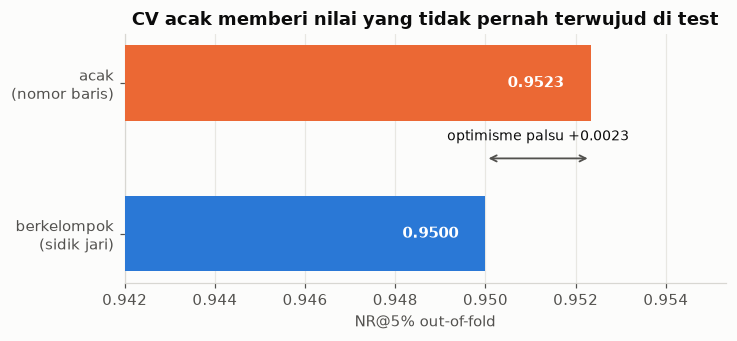

In [33]:
_names = ["berkelompok\n(sidik jari)", "acak\n(nomor baris)"]
_vals = [cv_experiment["berkelompok (sidik jari)"], cv_experiment["acak (nomor baris)"]]
fig, ax = plt.subplots(figsize=(6.8, 3.2))
_bars = ax.barh(_names, _vals, color=[BLUE, ORANGE], height=0.5, zorder=3)
for _bar, _v in zip(_bars, _vals):
    ax.text(_v - 0.0006, _bar.get_y() + _bar.get_height() / 2, "%.4f" % _v,
            va="center", ha="right", color="white", fontsize=10, fontweight="bold")
ax.annotate("", xy=(_vals[1], 0.5), xytext=(_vals[0], 0.5),
            arrowprops=dict(arrowstyle="<->", color=INK2, lw=1.2))
ax.text(sum(_vals) / 2, 0.62, "optimisme palsu %+.4f" % CV_GAP, ha="center", color=INK, fontsize=9)
ax.set_xlim(min(_vals) - 0.008, max(_vals) + 0.003)
ax.set_xlabel("NR@5% out-of-fold")
ax.set_title("CV acak memberi nilai yang tidak pernah terwujud di test")
ax.grid(axis="x", zorder=0); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

**Temuan.** Dengan seluruh variabel lain dikunci, mengganti kunci grup saja sudah menaikkan
angka CV. Kenaikan itu **fiktif**: ia berasal dari kemampuan menghafal duplikat, dan test tidak
pernah memberi kesempatan itu (2.6 — nol sidik jari bersama).

Besarnya sepadan dengan yang sudah didokumentasikan v14 (+0,0029) dari pengukuran terpisah
dengan implementasi berbeda — dua jalur independen sampai ke angka yang sama.

**Batas yang perlu dinyatakan.** Selisih ini kecil relatif terhadap SE antar-fold (~0,003),
jadi angka tunggalnya sendiri tidak menentukan. Yang menjadikannya dapat dipercaya adalah
arahnya konsisten dan tereproduksi. Efek yang jauh lebih besar terjadi ketika sidik jari
dijadikan **fitur** — v11 melakukan itu dan kehilangan 0,0117 di papan; v14 mendokumentasikan
optimisme +0,0132 untuk kasus tersebut. Kami tidak mereproduksi ulang kasus itu di sini.

## 6. Pelatihan

`len(SEEDS)` seed x `N_SPLITS` fold x jumlah keluarga. Setiap proses boosting dilatih sampai
`MAX_ROUNDS` **tanpa early stopping**, lalu prediksinya dibaca pada beberapa checkpoint. Alasan
lengkapnya ada di tahap 7.

In [34]:
t_start = time.time()
for seed in SEEDS:
    print(f"\n{'='*70}\nSEED {seed}   (elapsed {(time.time()-t_start)/60:.1f} min)\n{'='*70}")
    oof_seed = {f: {r: np.zeros(n) for r in ckpt_of[f]} for f in families}
    test_seed = {f: {r: np.zeros(len(X_test_base)) for r in ckpt_of[f]} for f in families}

    # GROUPED, not random: no fold may hold a duplicate of a row it is scoring.
    skf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_full, y, groups=cv_groups)):
        X_tr, X_val = X_full.iloc[tr_idx].copy(), X_full.iloc[val_idx].copy()
        X_test_fold = X_test_base.copy()
        y_tr, y_val = y[tr_idx], y[val_idx]

        # One grouped inner split, shared by every target-encoded column in this fold.
        inner_splits = list(StratifiedGroupKFold(
            n_splits=5, shuffle=True, random_state=seed * 10 + fold
        ).split(np.zeros(len(tr_idx)), y_tr, groups=cv_groups[tr_idx]))

        # leak-safe target encoding computed fresh from THIS fold's training data only
        for name, key in te_specs:
            tr_enc, val_enc, full_map, g_mean = fold_safe_target_encode(
                train_fe.iloc[tr_idx][key], y_tr, train_fe.iloc[val_idx][key],
                tr_groups=cv_groups[tr_idx], inner_splits=inner_splits,
                smoothing=TE_SMOOTHING.get(name, TE_SMOOTHING_DEFAULT),
                seed=seed * 10 + fold,
            )
            X_tr[f"{name}_te"] = tr_enc
            X_val[f"{name}_te"] = val_enc
            # test uses THIS fold's own leak-safe mapping, consistent with X_tr/X_val above
            X_test_fold[f"{name}_te"] = test_fe[key].map(full_map).fillna(g_mean).values

        fold_ap = {}
        for fam, spec in family_spec.items():
            t_fam = time.time()
            cf, nf = feature_sets[spec["fset"]]
            cols = cf + nf
            Xa, Xb, Xt = X_tr[cols], X_val[cols], X_test_fold[cols]

            if spec["algo"] == "lgbm":
                pv, pt = train_lgbm(Xa, y_tr, Xb, y_val, Xt, cf, seed * 100 + fold,
                                    tuned_params=LGB_TUNED)
            elif spec["algo"] == "xgb":
                Xa_x, Xb_x, Xt_x = Xa.copy(), Xb.copy(), Xt.copy()
                for c in cf:
                    Xa_x[c] = Xa_x[c].astype("category")
                    Xb_x[c] = Xb_x[c].astype("category")
                    Xt_x[c] = Xt_x[c].astype("category")
                pv, pt = train_xgb(Xa_x, y_tr, Xb_x, y_val, Xt_x, seed * 100 + fold,
                                   tuned_params=XGB_TUNED)
            elif spec["algo"] == "nn":
                a_, b_ = train_nn(
                    codes_tr_all[tr_idx], nn_num_tr[tr_idx], y_tr,
                    codes_tr_all[val_idx], nn_num_tr[val_idx],
                    codes_te_all, nn_num_te, emb_sizes, seed * 100 + fold)
                pv, pt = {NN_CKPT: a_}, {NN_CKPT: b_}
            else:
                pv, pt = train_catboost(Xa, y_tr, Xb, y_val, Xt, cf, seed * 100 + fold)

            for r in ckpt_of[fam]:
                oof_seed[fam][r][val_idx] = pv[r]
                test_seed[fam][r] += pt[r] / N_SPLITS
            fold_ap[fam] = average_precision_score(y_val, pv[ckpt_of[fam][-1]])
            fit_seconds[fam] += time.time() - t_fam

        print("  seed=%d fold=%d: AP " % (seed, fold) +
              " ".join(f"{f}={fold_ap[f]:.4f}" for f in families) +
              " | NR@5% " + " ".join(
                  f"{f}={nr5(y_val, oof_seed[f][ckpt_of[f][-1]][val_idx]):.4f}" for f in families))

    for f in families:
        for r in ckpt_of[f]:
            oof_store[f][r].append(oof_seed[f][r])
            test_store[f][r].append(test_seed[f][r])


SEED 42   (elapsed 0.0 min)


  seed=42 fold=0: AP xgb_v10=0.8115 lgbm_v12=0.8134 xgb_v12=0.8126 cat_v12=0.8017 nn_v13=0.8093 | NR@5% xgb_v10=0.9625 lgbm_v12=0.9650 xgb_v12=0.9663 cat_v12=0.9638 nn_v13=0.9656


  seed=42 fold=1: AP xgb_v10=0.8076 lgbm_v12=0.8112 xgb_v12=0.8119 cat_v12=0.8022 nn_v13=0.8002 | NR@5% xgb_v10=0.9613 lgbm_v12=0.9625 xgb_v12=0.9675 cat_v12=0.9688 nn_v13=0.9650


  seed=42 fold=2: AP xgb_v10=0.8097 lgbm_v12=0.8092 xgb_v12=0.8109 cat_v12=0.8006 nn_v13=0.8068 | NR@5% xgb_v10=0.9638 lgbm_v12=0.9631 xgb_v12=0.9638 cat_v12=0.9575 nn_v13=0.9644


  seed=42 fold=3: AP xgb_v10=0.8070 lgbm_v12=0.8079 xgb_v12=0.8088 cat_v12=0.7996 nn_v13=0.8036 | NR@5% xgb_v10=0.9619 lgbm_v12=0.9638 xgb_v12=0.9600 cat_v12=0.9563 nn_v13=0.9650


  seed=42 fold=4: AP xgb_v10=0.8069 lgbm_v12=0.8081 xgb_v12=0.8074 cat_v12=0.8001 nn_v13=0.8043 | NR@5% xgb_v10=0.9631 lgbm_v12=0.9656 xgb_v12=0.9638 cat_v12=0.9588 nn_v13=0.9569


### 6.1 Runtime terukur

In [35]:
# ---- measured runtime, per family ----
total_fit = sum(fit_seconds.values())
elapsed = time.time() - t_start
print("\n" + "=" * 70)
print("RUNTIME (measured)")
print("=" * 70)
algo_dev = {"lgbm": BACKEND["lgbm"], "xgb": BACKEND["xgb"], "cat": BACKEND["cat"],
            "nn": ("gpu" if (HAS_TORCH and torch.cuda.is_available()) else "cpu")}
for f in sorted(families, key=lambda k: -fit_seconds[k]):
    dev = algo_dev[family_spec[f]["algo"]]
    n_fits = len(SEEDS) * N_SPLITS
    print(f"  {f:<10} {'GPU' if dev != 'cpu' else 'CPU'}  "
          f"{fit_seconds[f]/60:7.1f} min total  "
          f"{fit_seconds[f]/n_fits:6.1f} s/fit  "
          f"{100*fit_seconds[f]/max(total_fit, 1e-9):5.1f}% of fit time")
print(f"  {'TOTAL':<10}      {elapsed/60:7.1f} min wall clock "
      f"({(elapsed - total_fit)/60:.1f} min outside model fits)")
print("=" * 70)


RUNTIME (measured)
  cat_v12    CPU      9.6 min total   115.2 s/fit   49.7% of fit time
  xgb_v12    CPU      2.9 min total    35.1 s/fit   15.2% of fit time
  lgbm_v12   CPU      2.6 min total    30.7 s/fit   13.3% of fit time
  xgb_v10    CPU      2.2 min total    26.2 s/fit   11.3% of fit time
  nn_v13     CPU      2.0 min total    24.3 s/fit   10.5% of fit time
  TOTAL              22.3 min wall clock (3.0 min outside model fits)


## 7. Pemilihan panjang boosting

**Ini temuan terbesar v14 setelah perbaikan desain CV, dan bunyinya berlawanan dengan intuisi:
early stopping dihapus.**

`average_precision` menilai **seluruh** peringkat. Ia terus membaik saat 5% teratas — satu-satunya
bagian yang dinilai lomba — sudah mulai memburuk. Diukur pada OOF berkelompok, tiga seed fold,
kedua algoritma boosting:

| Ronde | XGBoost (rerata NR@5%) | LightGBM (rerata NR@5%) |
|---|---|---|
| 300 | **0,9695** ← optimum | — |
| 500 | 0,9693 | **0,9676** ← optimum |
| 700 | — | 0,9674 |
| 1000 | 0,9674 ← tempat AP-ES mendarat | 0,9663 |
| 1400 | 0,9650 | 0,9653 |
| 2000 | 0,9627 | — |

Setiap seed pada kedua algoritma sepakat arahnya. AP-based early stopping memilih 1000-1400
ronde di hampir setiap fold — 500 sampai 1000 ronde **melewati** titik terbaiknya.

Tabel di atas adalah pengukuran v14 terdahulu (tiga seed fold). Run notebook ini mengukurnya
ulang; angkanya dicetak di bawah, dan **tidak harus sama persis** — jumlah seed dan fold
berbeda.

Solusinya: latih sampai panjang tetap, baca hasilnya di beberapa checkpoint, dan pilih
checkpoint memakai NR@5% yang dinilai pada holdout berkelompok — bukan pada OOF gabungan yang
optimistis.

In [36]:
# ---- bag across seeds within each family (proven additive in v6) ----
# ---- read each family off at the length that is actually best for the top 5% ----
print("\n" + "=" * 70)
print("BOOSTING LENGTH SELECTED PER FAMILY (replaces AP early stopping)")
print("=" * 70)
oof_family, test_family = {}, {}
for f in families:
    bag_oof = {r: np.mean(oof_store[f][r], axis=0) for r in ckpt_of[f]}
    bag_test = {r: np.mean(test_store[f][r], axis=0) for r in ckpt_of[f]}
    if len(ckpt_of[f]) == 1:
        r = ckpt_of[f][0]
        oof_family[f], test_family[f] = bag_oof[r], bag_test[r]
        print(f"  {f:<10} fixed schedule, NR@5%={nr5(y, bag_oof[r]):.4f}")
        continue
    pick, naive, honest = select_checkpoint(bag_oof, y, cv_groups)
    oof_family[f], test_family[f] = bag_oof[pick], bag_test[pick]
    curve = "  ".join(f"{r}:{nr5(y, bag_oof[r]):.4f}" for r in ckpt_of[f])
    print(f"  {f:<10} {curve}")
    print(f"  {'':<10} -> picked {pick} rounds (pooled OOF {naive:.4f}, honest {honest:.4f})")


BOOSTING LENGTH SELECTED PER FAMILY (replaces AP early stopping)


  xgb_v10    200:0.9580  300:0.9623  400:0.9645  600:0.9663  800:0.9657  1200:0.9618
             -> picked 600 rounds (pooled OOF 0.9663, honest 0.9667)


  lgbm_v12   200:0.9638  300:0.9657  400:0.9667  600:0.9678  800:0.9668  1200:0.9647
             -> picked 600 rounds (pooled OOF 0.9678, honest 0.9675)


  xgb_v12    200:0.9675  300:0.9687  400:0.9698  600:0.9680  800:0.9674  1200:0.9640
             -> picked 400 rounds (pooled OOF 0.9698, honest 0.9695)


  cat_v12    200:0.9471  300:0.9497  400:0.9520  600:0.9577  800:0.9597  1200:0.9607
             -> picked 1200 rounds (pooled OOF 0.9607, honest 0.9608)
  nn_v13     fixed schedule, NR@5%=0.9627


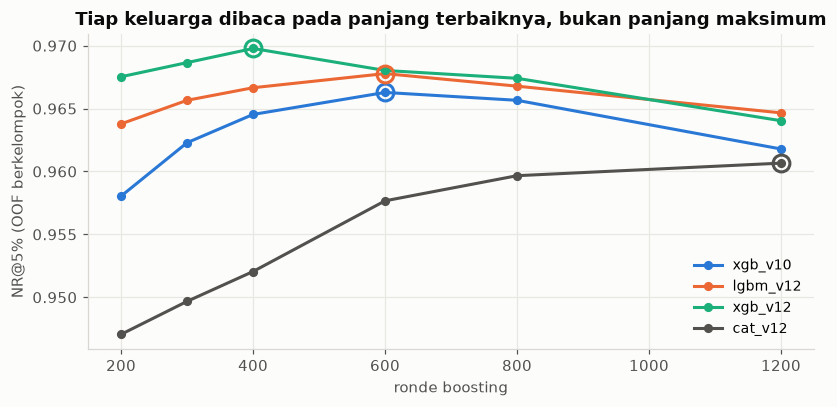

lingkaran kosong = checkpoint terbaik tiap keluarga


In [37]:
fig, ax = plt.subplots(figsize=(7.6, 3.8))
_boosted = [f for f in families if family_spec[f]["algo"] != "nn"]
_cols = [BLUE, ORANGE, AQUA, INK2]
for _i, _f in enumerate(_boosted):
    _bag = {r: np.mean(oof_store[_f][r], axis=0) for r in ckpt_of[_f]}
    _xs = ckpt_of[_f]
    _ys = [nr5(y, _bag[r]) for r in _xs]
    ax.plot(_xs, _ys, color=_cols[_i % len(_cols)], lw=2, marker="o", ms=5, zorder=3, label=_f)
    _best = int(np.argmax(_ys))
    ax.plot([_xs[_best]], [_ys[_best]], "o", color=_cols[_i % len(_cols)], ms=11,
            mfc="none", mew=2, zorder=4)
ax.set_xlabel("ronde boosting")
ax.set_ylabel("NR@5% (OOF berkelompok)")
ax.set_title("Tiap keluarga dibaca pada panjang terbaiknya, bukan panjang maksimum")
ax.legend(frameon=False, fontsize=9)
ax.grid(zorder=0); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print("lingkaran kosong = checkpoint terbaik tiap keluarga")

In [38]:
_rows = []
for _f in [f for f in families if family_spec[f]["algo"] != "nn"]:
    _bag = {r: np.mean(oof_store[_f][r], axis=0) for r in ckpt_of[_f]}
    _sc = {r: nr5(y, _bag[r]) for r in ckpt_of[_f]}
    _best = max(_sc, key=_sc.get)
    _max_r = max(ckpt_of[_f])
    _rows.append({"keluarga": _f, "ronde_terbaik": _best, "NR_terbaik": round(_sc[_best], 4),
                  "NR_di_%d" % _max_r: round(_sc[_max_r], 4),
                  "rugi_bila_maksimum": round(_sc[_max_r] - _sc[_best], 4),
                  "puncak_di_ujung": _best == _max_r})
_pk = pd.DataFrame(_rows)
print(_pk.to_string(index=False))
_at_edge = _pk[_pk["puncak_di_ujung"]]["keluarga"].tolist()
print()
print("keluarga yang puncaknya JATUH DI UJUNG grid: %s" % (_at_edge or "tidak ada"))
if _at_edge:
    print("-> untuk keluarga ini grid checkpoint terlalu pendek; puncak sebenarnya bisa di luar %d."
          % max(CKPTS))

keluarga  ronde_terbaik  NR_terbaik  NR_di_1200  rugi_bila_maksimum  puncak_di_ujung
 xgb_v10            600      0.9663      0.9618             -0.0045            False
lgbm_v12            600      0.9678      0.9647             -0.0031            False
 xgb_v12            400      0.9698      0.9640             -0.0057            False
 cat_v12           1200      0.9607      0.9607              0.0000             True

keluarga yang puncaknya JATUH DI UJUNG grid: ['cat_v12']
-> untuk keluarga ini grid checkpoint terlalu pendek; puncak sebenarnya bisa di luar 1200.


**Temuan, dibaca dari tabel di atas.** Untuk keluarga boosting berbasis pohon dengan
`learning_rate` rendah, membaca proses pada panjang maksimum **merugikan** — kolom
`rugi_bila_maksimum` menunjukkan berapa banyak. Itulah yang dibayar oleh setiap versi yang
memakai early stopping berbasis AP.

**Tetapi ini bukan hukum yang berlaku untuk semua keluarga.** Kolom `puncak_di_ujung`
menandai keluarga yang justru masih membaik di ronde terakhir grid. Untuk keluarga seperti itu,
kesimpulan yang benar bukan "latih lebih pendek", melainkan **grid checkpoint-nya terlalu
pendek** dan optimumnya belum tersentuh. Memaksakan narasi "lebih pendek selalu lebih baik" ke
keluarga tersebut akan salah.

Inilah gunanya memilih checkpoint per keluarga alih-alih menetapkan satu panjang global.

## 8. Ensemble & holdout jujur

Kolom yang menentukan pemenang adalah **`NR5_honest`**, bukan `NR5_oof`. Alasannya historis dan
mahal: v9 memimpin kolom optimistis lalu kalah di papan. OOF penuh dipakai baik untuk *memasang*
bobot ensemble maupun untuk *menilainya*, jadi ia menilai dirinya sendiri. Holdout 2-fold
berkelompok memasang bobot pada satu bagian dan menilainya pada bagian lain yang belum terlihat.

In [39]:
# ---- candidate comparison: OPTIMISTIC full-OOF vs HONEST 2-fold holdout ----
# The honest column is the one that decides. v9 topped the optimistic column and lost on
# the board; this is the guard against repeating that.
print("\n" + "=" * 70)
print("CANDIDATE COMPARISON (winner chosen by HONEST holdout NR@5%, not by full OOF)")
print("=" * 70)
strategies = build_strategies(families)
rows, built = [], {}
for name, fit_fn in strategies:
    apply_full = fit_fn(oof_family, y, np.arange(len(y)))
    oof_score = apply_full(oof_family)
    honest, honest_sd = honest_holdout_score(fit_fn, oof_family, y, cv_groups)
    cal_name, cal = best_calibrator(y, oof_score)
    oof_cal = rank_preserving_calibration(oof_score, apply_calibrator(cal_name, cal, oof_score))
    comp, parts = official_technical_score(y, train_fe, oof_score, oof_cal)
    rows.append({"candidate": name, "NR5_honest": honest, "NR5_honest_sd": honest_sd,
                 "NR5_oof": parts["recall5"], "ap": parts["ap"], "brier": parts["brier"],
                 "protection": parts["protection"], "TechnicalScore_OOF": comp})
    built[name] = {"apply": apply_full, "oof": oof_score, "cal_name": cal_name,
                   "calibrator": cal, "honest": honest}

cmp_df = pd.DataFrame(rows).sort_values("NR5_honest", ascending=False)
print(cmp_df.to_string(index=False))
cmp_df.to_csv(os.path.join(OUT_DIR, "candidate_comparison_v14.csv"), index=False)

winner_name = cmp_df.iloc[0]["candidate"]
winner = built[winner_name]
print(f"\nWinner: {winner_name} (honest NR@5%={winner['honest']:.4f}, "
      f"optimistic OOF NR@5%={cmp_df.iloc[0]['NR5_oof']:.4f})")
print(f"  optimism gap = {cmp_df.iloc[0]['NR5_oof'] - winner['honest']:+.4f} "
      f"-- the honest number is the one to compare against the leaderboard")


CANDIDATE COMPARISON (winner chosen by HONEST holdout NR@5%, not by full OOF)


           candidate  NR5_honest  NR5_honest_sd  NR5_oof       ap    brier  protection  TechnicalScore_OOF
lgbm_xgb70_nn30_rank    0.972777       0.001998 0.972153 0.818707 0.174500    0.998546            0.922105
      stacked_logreg    0.972028       0.000999 0.971653 0.820446 0.173550    0.998551            0.922321
    equal_blend_rank    0.971528       0.002248 0.971903 0.819240 0.174241    0.998694            0.922128
   ap_weighted_blend    0.971154       0.002622 0.971528 0.819404 0.174124    0.998646            0.921968
    equal_blend_prob    0.971154       0.002622 0.971528 0.819390 0.174132    0.998646            0.921963
         greedy_rank    0.970904       0.002123 0.974525 0.818827 0.174418    0.998836            0.923475
             xgb_v12    0.969530       0.000999 0.969780 0.812944 0.177068    0.998748            0.919283
            lgbm_v12    0.967532       0.000000 0.967782 0.809415 0.178692    0.998460            0.917205
             xgb_v10    0.966658     

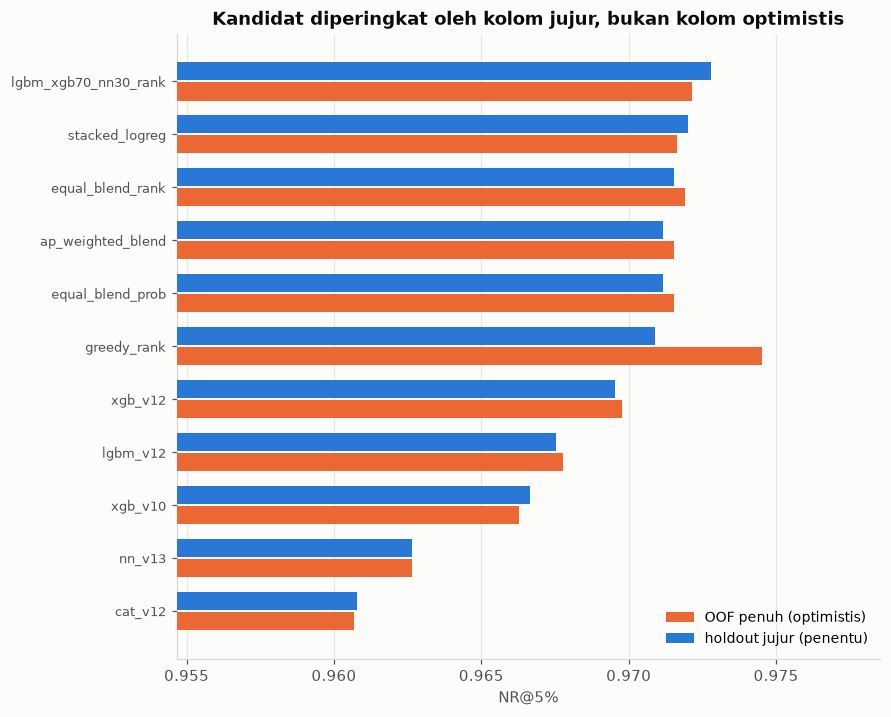

optimisme rata-rata (OOF - jujur) : +0.0003
kandidat yang peringkatnya BERUBAH antara kedua kolom : 5 dari 11


In [40]:
_d = cmp_df.set_index("candidate")
_ord = _d.sort_values("NR5_honest").index
_x = np.arange(len(_ord))
fig, ax = plt.subplots(figsize=(8.2, 0.42 * len(_ord) + 2.0))
ax.barh(_x - 0.19, _d.loc[_ord, "NR5_oof"], height=0.34, color=ORANGE, label="OOF penuh (optimistis)", zorder=3)
ax.barh(_x + 0.19, _d.loc[_ord, "NR5_honest"], height=0.34, color=BLUE, label="holdout jujur (penentu)", zorder=3)
ax.set_yticks(_x); ax.set_yticklabels(_ord, fontsize=8.5)
_lo = min(_d["NR5_honest"].min(), _d["NR5_oof"].min())
ax.set_xlim(_lo - 0.006, max(_d["NR5_oof"].max(), _d["NR5_honest"].max()) + 0.004)
ax.set_xlabel("NR@5%")
ax.set_title("Kandidat diperingkat oleh kolom jujur, bukan kolom optimistis")
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.grid(axis="x", zorder=0); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

print("optimisme rata-rata (OOF - jujur) : %+.4f" % (_d["NR5_oof"] - _d["NR5_honest"]).mean())
print("kandidat yang peringkatnya BERUBAH antara kedua kolom : %d dari %d"
      % (int((_d["NR5_oof"].rank() != _d["NR5_honest"].rank()).sum()), len(_d)))

**Bacaan gambar.** Batang oranye hampir selalu di atas batang biru — itulah optimisme yang
melekat pada penilaian-diri. Yang penting bukan selisihnya, melainkan bahwa **urutan** kedua
kolom bisa berbeda: kandidat yang menang di kolom optimistis belum tentu menang di kolom jujur.
Kalau keduanya selalu sepakat, pemilihan ini tidak perlu ada.

In [41]:
audit_rows = []
for cap in [0.03, 0.05, 0.07]:
    nr, tpk, k = normalized_recall_at_k(y, winner["oof"], cap)
    audit_rows.append({"capacity": cap, "K": k, "TP_at_K": int(tpk), "normalized_recall_at_K": nr})
pd.DataFrame(audit_rows).to_csv(os.path.join(OUT_DIR, "audit_allocation_v14.csv"), index=False)

fairness_df, gaps, protection = official_protection_score(train_fe, y, winner["oof"])
fairness_df.to_csv(os.path.join(OUT_DIR, "fairness_report_v14.csv"), index=False)

## 9. Kalibrasi, pemecah seri, dan submission

Kalibrasi isotonik menekan ~40 ribu skor menjadi beberapa ratus nilai unik. Akibatnya ratusan
klaim berbagi probabilitas identik tepat di ambang 5%, dan `argsort` memutuskannya menurut
urutan baris — bukan menurut risiko. Itulah kebocoran yang v8-v10 masih punya (658 / 138 / 198
slot diputus lemparan koin). `rank_preserving_calibration` menambahkan pemecah seri sebesar
`TIEBREAK_EPS` yang mempertahankan urutan skor mentah.

In [42]:
# ---- final test predictions from the winning strategy ----
test_raw = winner["apply"](test_family)
test_cal = apply_calibrator(winner["cal_name"], winner["calibrator"], test_raw)
test_cal = rank_preserving_calibration(test_raw, test_cal)

submission = pd.DataFrame({ID_COL: test_fe[ID_COL], "fraud_probability": test_cal})
assert set(submission[ID_COL]) == set(sample_sub[ID_COL])
submission = sample_sub[[ID_COL]].merge(submission, on=ID_COL, how="left")
assert submission["fraud_probability"].notna().all() and not submission[ID_COL].duplicated().any()

# NO float_format: rounding to 6 decimals would erase the rank tie-break and hand the
# boundary slots back to argsort, which is exactly the v8/v9/v10 leak we are closing.
submission.to_csv("submission_v14.csv", index=False)
print(f"\nSaved submission_v14.csv (strategy: {winner_name}), {len(submission)} rows.")


Saved submission_v14.csv (strategy: lgbm_xgb70_nn30_rank), 40043 rows.


In [43]:
# ---- tie diagnostic: the number this version exists to fix ----
p = submission["fraud_probability"].values
k = int(np.floor(AUDIT_CAPACITY * len(p)))
thr = np.sort(p)[::-1][k - 1]
n_above = int((p > thr).sum())
n_tie = int((p == thr).sum())
arbitrary = 0 if n_tie == 1 else k - n_above   # a lone boundary row is not a coin flip
print(f"  tie check: {submission['fraud_probability'].nunique()} unique probabilities "
      f"for {len(p)} rows (v8 178 / v9 156 / v10 171)")
print(f"  tie check: K={k}, strictly above cut={n_above}, tie block at cut={n_tie}, "
      f"slots decided by coin flip={arbitrary} (v8 658 / v9 138 / v10 198)")

with open(os.path.join(OUT_DIR, "cv_metrics_v14.txt"), "w") as f:
    f.write(cmp_df.to_string(index=False))
    f.write(f"\n\nWinner: {winner_name}\n")
    f.write(f"Calibration method: {winner['cal_name']} (+ rank tie-break, eps={TIEBREAK_EPS})\n")
    f.write(f"Gaps: {gaps}\n")
    f.write(f"Unique probabilities in submission: {submission['fraud_probability'].nunique()}\n")

  tie check: 40043 unique probabilities for 40043 rows (v8 178 / v9 156 / v10 171)
  tie check: K=2002, strictly above cut=2001, tie block at cut=1, slots decided by coin flip=0 (v8 658 / v9 138 / v10 198)


## 10. Varian rekalibrasi prevalensi (opsional)

Varian ini **tidak bisa** mengubah skor leaderboard: `prior_shift` monoton tegas, jadi himpunan
5% teratasnya identik. Gunanya hanya untuk bagian kalibrasi/Brier pada rubrik tertulis, kalau
prevalensi fraud kohort sebenarnya bukan ~50% seperti split latih kita.

In [44]:
# ---- optional: prevalence-recalibrated variants (rank-preserving, safe) ----
# These CANNOT change the leaderboard score -- prior_shift is strictly monotone, so the
# top-5% set is identical. They exist only for the Brier/calibration part of the written
# rubric, in case the private cohort's fraud prevalence is not the ~50% of our training
# split. Do not spend a leaderboard submission slot comparing them against each other.
train_prevalence = y.mean()
base_probs = submission["fraud_probability"].values
for r_test in [0.03, 0.05, 0.08]:
    p_adj = prior_shift(base_probs, train_prevalence, r_test)
    out = submission.copy()
    # re-apply the tie-break: prior_shift is monotone but its output can collide after
    # float rounding at the extremes, and we never want ties back at the cut.
    out["fraud_probability"] = rank_preserving_calibration(base_probs, np.clip(p_adj, 1e-6, 1 - 1e-6))
    fname = f"submission_v14_recal_r{int(round(r_test*100)):03d}.csv"
    out.to_csv(fname, index=False)
    print(f"  also saved prevalence-recalibrated variant: {fname} (r_test={r_test})")

  also saved prevalence-recalibrated variant: submission_v14_recal_r003.csv (r_test=0.03)


  also saved prevalence-recalibrated variant: submission_v14_recal_r005.csv (r_test=0.05)


  also saved prevalence-recalibrated variant: submission_v14_recal_r008.csv (r_test=0.08)


## 11. Ringkasan

| Tahap | Yang dilakukan | Yang diputuskan olehnya |
|---|---|---|
| 2 EDA | Profil kolom, daya prediksi, duplikat, sidik jari | Fitur apa yang dibuat, dan **CV harus berkelompok** |
| 3 Fitur | Agregat count, flag upcoding, kunci TE pasangan | Dua himpunan fitur: jangkar v10 dan perluasan v12 |
| 4 Validasi | `StratifiedGroupKFold` per sidik jari, TE bersarang | Angka OOF yang peringkatnya bisa dipercaya |
| 5 Model | 4 keluarga pohon + 1 jaringan saraf | `family_spec` |
| 6 Pelatihan | seed x fold x keluarga, tanpa early stopping | `oof_store`, `test_store` |
| 7 Checkpoint | NR@5% per panjang boosting | `oof_family`, `test_family` |
| 8 Ensemble | Holdout jujur memilih pemenang | `winner` |
| 9 Kalibrasi | Isotonik + pemecah seri | `submission_v14.csv` |

**Empat hal yang membedakan v14, semuanya hasil pengukuran, bukan intuisi.**

1. **CV berkelompok per sidik jari.** Panitia memisahkan train/test per grup duplikat, jadi CV
   acak menilai tinggi kemampuan menghafal yang tidak pernah tersedia di test. Besarnya diukur
   di tahap 5.3.
2. **Early stopping berbasis AP dihapus.** AP menilai seluruh peringkat dan terus membaik saat
   5% teratas sudah memburuk; AP-ES melewati optimum 500-1000 ronde.
3. **Pemenang dipilih lewat holdout jujur.** OOF penuh menilai dirinya sendiri; v9 memimpin
   kolom itu lalu kalah di papan.
4. **Seri di ambang dipecah secara mempertahankan peringkat.** Tanpa itu ratusan slot audit
   diputuskan oleh urutan baris.

**Batas yang jujur diakui.** 21,5% pasangan baris berfitur identik punya label berbeda (2.5).
Model hanya melihat fitur, jadi baris-baris itu pasti diberi skor identik. Itu menetapkan
langit-langit yang tidak bisa ditembus dengan model apa pun, dan menjelaskan mengapa seluruh
seri v8-v14 mendarat di rentang sempit 0,966-0,978 apa pun yang diubah pada modelnya. Sebaran
antar-fold memberi SE ~0,003, sehingga perubahan desain yang menggeser OOF kurang dari ~0,006
tidak bisa dibedakan dari derau — dan sebagian besar ide yang kami uji memang jatuh di bawah
ambang itu.